# Model Development & Tracking
Covers **Stage 2.2–2.4 + Stage 3.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports.

- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** —
- *Provided:* `config.py`, `src/evaluate.py`.
- *Provided to extend:* `src/model.py`, `src/train.py`, `app.py`.
- *You build:* this notebook.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys

PROJECT_DIR = Path("/content/drive/MyDrive/Casting_Defect_MLOps_Capstone")
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Working directory:", Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone


In [2]:
%pip install -r "/content/drive/MyDrive/Casting_Defect_MLOps_Capstone/requirements.txt"

### 0. Setup

In [3]:
# TODO: imports (torch, mlflow, pandas, matplotlib) as needed
import ast
import hashlib
import importlib
import json
import shutil
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from IPython.core.magic import register_cell_magic
from IPython.display import Image as DisplayImage, Markdown, display

import config
from src import data_prep

required_files = [
    "config.py", "src/data_prep.py", "src/evaluate.py",
    "src/model.py", "src/train.py", "app.py",
]
missing = [f for f in required_files if not (PROJECT_DIR / f).is_file()]
if missing:
    raise FileNotFoundError(f"Missing project files: {missing}")

# ---- Confirm we use the dataset version built in Data_Preparation.ipynb ----
DATA_VERSION = "v1"
root = data_prep.find_data_root()
split_meta_path = Path(config.SPLIT_DIR) / DATA_VERSION / "metadata.json"
if not split_meta_path.is_file():
    raise FileNotFoundError(
        f"{split_meta_path} not found. Run Data_Preparation.ipynb first."
    )
split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))

if Path(split_meta["dataset_root"]).resolve() != Path(root).resolve():
    raise ValueError(
        f"Split {DATA_VERSION} was built from {split_meta['dataset_root']}, but "
        f"find_data_root() now returns {root}. Remove the extra dataset folder "
        "or rebuild the split so training and evaluation use the same data."
    )

print("Dataset root:", root)
print("Split sizes:", {k: v["size"] for k, v in split_meta["split_info"].items()})
if split_meta["original_image_count"] != 7348:
    print(
        f"WARNING: split {DATA_VERSION} has {split_meta['original_image_count']} "
        "images, not the full 7,348 — results will not reflect the full dataset."
    )

print("Class mapping:", config.CLASS_TO_IDX, "| positive class:", config.POSITIVE_CLASS)
print(
    "Device:", "cuda" if torch.cuda.is_available() else "cpu",
    "| torch", torch.__version__, "| mlflow", mlflow.__version__,
)

# ---- Helpers ----
BACKUP_DIR = Path(config.ARTIFACT_DIR) / "backups" / "src"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)
EVIDENCE_DIR = PROJECT_DIR / "submission" / "evidence"
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)


def backup_file(path):
    """Copy a file to BACKUP_DIR once per distinct content."""
    digest = hashlib.sha256(path.read_bytes()).hexdigest()[:10]
    target = BACKUP_DIR / f"{path.stem}_{digest}{path.suffix}"
    if not target.exists():
        shutil.copy2(path, target)
    return target


def _defined_names(source):
    """Top-level functions, classes and variables (imports excluded)."""
    names = set()
    for node in ast.parse(source).body:
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
            names.add(node.name)
        elif isinstance(node, ast.Assign):
            names.update(t.id for t in node.targets if isinstance(t, ast.Name))
        elif isinstance(node, ast.AnnAssign) and isinstance(node.target, ast.Name):
            names.add(node.target.id)
    return names


def _carry_over_block(old_source, new_source, names):
    old_lines = old_source.splitlines()
    new_imports = {
        ast.get_source_segment(new_source, node)
        for node in ast.parse(new_source).body
        if isinstance(node, (ast.Import, ast.ImportFrom))
    }
    imports, definitions = [], []
    for node in ast.parse(old_source).body:
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            if isinstance(node, ast.ImportFrom) and node.module == "__future__":
                continue
            text = ast.get_source_segment(old_source, node)
            if text not in new_imports and text not in imports:
                imports.append(text)
            continue
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
            defined = {node.name}
        elif isinstance(node, ast.Assign):
            defined = {t.id for t in node.targets if isinstance(t, ast.Name)}
        elif isinstance(node, ast.AnnAssign) and isinstance(node.target, ast.Name):
            defined = {node.target.id}
        else:
            continue
        if defined & set(names):
            start = min([node.lineno] + [d.lineno for d in getattr(node, "decorator_list", [])])
            definitions.append("\n".join(old_lines[start - 1:node.end_lineno]))
    header = "# ---- Kept from the previous version of this file ----"
    if imports:
        header += "\n" + "\n".join(imports)
    return "\n\n\n".join([header] + definitions)


def _insert_before_main_guard(source, block):
    lines = source.rstrip("\n").splitlines()
    guard = next(
        (node for node in ast.parse(source).body
         if isinstance(node, ast.If)
         and "__name__" in ast.get_source_segment(source, node.test)),
        None,
    )
    if guard is None:
        return "\n".join(lines).rstrip() + "\n\n\n" + block + "\n"
    before = "\n".join(lines[:guard.lineno - 1]).rstrip()
    after = "\n".join(lines[guard.lineno - 1:])
    return before + "\n\n\n" + block + "\n\n\n" + after + "\n"


@register_cell_magic
def write_module(line, cell):
    """%%write_module src/x.py [--keep-missing | --force]"""
    args = line.split()
    if not args:
        raise ValueError("Usage: %%write_module <path> [--keep-missing | --force]")
    rel_path = args[0]
    path = PROJECT_DIR / rel_path
    source = cell.rstrip() + "\n"
    new_names = _defined_names(source)  # a SyntaxError here writes nothing

    if path.is_file():
        old_source = path.read_text(encoding="utf-8")
        try:
            old_names = _defined_names(old_source)
        except SyntaxError:
            old_names = set()
        dropped = sorted(n for n in old_names - new_names if not n.startswith("_"))

        if dropped and "--keep-missing" in args[1:]:
            block = _carry_over_block(old_source, source, dropped)
            source = _insert_before_main_guard(source, block)
            new_names = _defined_names(source)
            print(f"Kept from the existing {rel_path}: {', '.join(dropped)}")
            print(block)
            print("-" * 60)
            dropped = []

        if old_source == source:
            print(f"{rel_path} already up to date")
            return
        if dropped and "--force" not in args[1:]:
            raise ValueError(
                f"Writing {rel_path} would remove {dropped}. Add them to this "
                "cell, or use --keep-missing to keep the existing versions."
            )
        print("Backup:", backup_file(path))

    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(source, encoding="utf-8")

    module_name = ".".join(Path(rel_path).with_suffix("").parts)
    if module_name in sys.modules:
        importlib.invalidate_caches()
        importlib.reload(sys.modules[module_name])
    print(f"Wrote {rel_path}: {', '.join(sorted(new_names))}")


def run_and_stream(command, title, check=True):
    """Run a command in PROJECT_DIR, stream its output, return the exit code."""
    print(f"--- {title} ---")
    process = subprocess.Popen(
        command, cwd=PROJECT_DIR, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for output_line in process.stdout:
        print(output_line, end="", flush=True)
    exit_code = process.wait()
    if check and exit_code != 0:
        raise RuntimeError(f"{title} failed with exit code {exit_code}")
    return exit_code


def upload_evidence(expected_names):
    """Upload screenshots from your computer into submission/evidence (Colab)."""
    from google.colab import files
    for name, data in files.upload().items():
        if name in expected_names:
            (EVIDENCE_DIR / name).write_bytes(data)
            print("Saved:", EVIDENCE_DIR / name)
        else:
            print(f"Ignored {name}: expected one of {expected_names}")


def show_evidence(filename, title):
    path = EVIDENCE_DIR / filename
    print(f"{title}: {path}")
    if path.is_file():
        display(DisplayImage(filename=str(path)))
    else:
        print("  Screenshot not found yet.")
    return path.is_file()

Dataset root: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/data/casting_data
Split sizes: {'train': 5583, 'val': 986, 'test': 715}
Class mapping: {'ok_front': 0, 'def_front': 1} | positive class: def_front
Device: cpu | torch 2.8.0+cu128 | mlflow 3.1.4


## **Stage 2.2 — Transfer-Learning Model** <font color="red">[7 marks]</font>

- **2.2.1 — ImageNet-pretrained ResNet18, backbone frozen [4]**
- **2.2.2 — New 2-class head replaces fc (head trained) [3]**

**Objective:** Build an ImageNet-pretrained ResNet18 with a frozen backbone + new 2-class head.

**Implement in:** src/model.build_model

**Inputs → Outputs:** → a torch model; only the head's params have requires_grad=True

**TODO:** load weights=IMAGENET1K + freeze the backbone (2.2.1); replace fc with a 2-class Linear head so only the head trains (2.2.2); print total vs trainable params.

**Depends on:** Stage 2.1 transformations completed in Data_Preparation.ipynb  ·  **Document here:** the param counts (trainable should be ~the head only).

In [4]:
%%write_module src/model.py --keep-missing
"""Stage 2.2: ImageNet-pretrained ResNet18 with a frozen backbone and 2-class head."""
from pathlib import Path

import torch
import torch.nn as nn
from torchvision.models import ResNet18_Weights, resnet18

import config


def build_model(pretrained=True):
    """Build ResNet18 with a frozen backbone and a trainable 2-class head."""
    if config.NUM_CLASSES != 2:
        raise ValueError("This stage expects exactly two classes.")

    weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = resnet18(weights=weights)

    # 2.2.1: freeze every pretrained parameter.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # 2.2.2: replace the 1000-class ImageNet head; new layers train by default.
    model.fc = nn.Linear(model.fc.in_features, config.NUM_CLASSES)

    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    return model


def trainable_parameters(model):
    """Return trainable parameters for the optimizer."""
    return [parameter for parameter in model.parameters() if parameter.requires_grad]


def parameter_counts(model):
    """Return total, trainable, and frozen parameter counts."""
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )
    return {"total": total, "trainable": trainable, "frozen": total - trainable}


def save_model(model, path=None):
    """Save the model's weights (state_dict) to path (default: config.MODEL_PATH)."""
    path = Path(path or config.MODEL_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path


def load_model(checkpoint=None, device=None):
    """Load a saved checkpoint without downloading pretrained weights."""
    checkpoint_path = Path(checkpoint or config.MODEL_PATH)

    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Model checkpoint not found: {checkpoint_path}")

    if device is None:
        device = config.DEVICE
        if device != "cpu" and not torch.cuda.is_available():
            device = "cpu"

    device = torch.device(device)
    model = build_model(pretrained=False)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


class EmbeddingExtractor(nn.Module):
    """Extract 512-d feature vectors from a ResNet before its classifier."""

    def __init__(self, model):
        super().__init__()
        self.backbone = nn.Sequential(*list(model.children())[:-1])

    def forward(self, images):
        return self.backbone(images).flatten(start_dim=1)

src/model.py already up to date


In [5]:
# TODO 2.2.1-2.2.2: from src.model import build_model, trainable_parameters; build + print params
from src import model as model_module

importlib.reload(model_module)

model = model_module.build_model(pretrained=True)
counts = model_module.parameter_counts(model)
trainable_names = [name for name, p in model.named_parameters() if p.requires_grad]

display(pd.DataFrame([
    {"parameters": "total", "count": f"{counts['total']:,}"},
    {"parameters": "trainable (head)", "count": f"{counts['trainable']:,}"},
    {"parameters": "frozen (backbone)", "count": f"{counts['frozen']:,}"},
]))
print("Classifier:", model.fc)
print("Trainable tensors:", trainable_names)
print(f"Trainable share: {100 * counts['trainable'] / counts['total']:.4f}%")

model.eval()
dummy = torch.zeros(2, 3, config.IMG_SIZE, config.IMG_SIZE)
with torch.no_grad():
    logits = model(dummy)
    embeddings = model_module.EmbeddingExtractor(model)(dummy)

assert set(trainable_names) == {"fc.weight", "fc.bias"}
assert counts["trainable"] == model.fc.weight.numel() + model.fc.bias.numel()
assert len(model_module.trainable_parameters(model)) == 2
assert tuple(logits.shape) == (2, config.NUM_CLASSES)
assert tuple(embeddings.shape) == (2, model.fc.in_features)

print("Logits shape:", tuple(logits.shape), "| embedding shape:", tuple(embeddings.shape))
print("PASS: frozen ImageNet backbone, trainable two-class head.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


,parameters,count
0,total,"11,177,538"
1,trainable (head),"1,026"
2,frozen (backbone),"11,176,512"


Classifier: Linear(in_features=512, out_features=2, bias=True)
Trainable tensors: ['fc.weight', 'fc.bias']
Trainable share: 0.0092%
Logits shape: (2, 2) | embedding shape: (2, 512)
PASS: frozen ImageNet backbone, trainable two-class head.


### 2.2 Model — findings

| Parameters | Count |
|---|---|
| Total | 11,177,538 |
| Trainable: the new `fc` head (512 × 2 weights + 2 biases) | **1,026** (0.009%) |
| Frozen: the ImageNet backbone | 11,176,512 |

- **2.2.1 Frozen pretrained backbone.** ResNet18 is loaded with `IMAGENET1K_V1` weights, and every backbone parameter has `requires_grad=False`. During training the backbone is also kept in `eval()` mode. That keeps its BatchNorm running statistics at their ImageNet values instead of letting them drift on the small casting dataset.
- **2.2.2 New head.** The 1000-class ImageNet `fc` layer is replaced by `Linear(512, 2)`. Only `fc.weight` and `fc.bias` are trainable, and only they are passed to the optimiser.
- **Why freeze the backbone.**
  - About 5.6k training images is small for 11M parameters. Training only the head greatly reduces the risk of overfitting and takes minutes rather than hours.
  - Low-level ImageNet features such as edges and textures transfer well to surface defects.
  - The trade-off is that these features are not specialised for castings. Unfreezing `layer4` at a low learning rate is the natural next experiment if defect recall plateaus.
- **`EmbeddingExtractor`** returns the 512-d features from just before the head. Stage 4 uses them for drift monitoring.

## **Stage 2.3 — Training Workflow** <font color="red">[6 marks]</font>

- **2.3.1 — Class-weighted loss + optimiser (trainable params) + seed [3]**
- **2.3.2 — Epoch loop + validation eval + early stopping [3]**

**Objective:** Train the head reproducibly with validation + early stopping.

**Implement in:** src/train.py

**Inputs → Outputs:** splits + model → trained model.pt + model_meta.json

**TODO:** class-weighted CrossEntropy + Adam over TRAINABLE params only + seed 42 (2.3.1); epoch loop with val evaluation + early stop on val-F1 (2.3.2).

**Document here:** the training summary (final val F1, epochs).

In [7]:
# Writes the complete src/train.py directly (no %%write_module needed).
from pathlib import Path
import shutil
import time

TRAIN_SOURCE = r'''"""Stages 2.3, 2.4 and 3.2: train the head, track it in MLflow, register it."""
import copy
import json
import random
from pathlib import Path

import mlflow
import mlflow.pytorch
import numpy as np
import torch
from mlflow import MlflowClient
from mlflow.exceptions import MlflowException
from mlflow.models import infer_signature
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score
from torch import nn
from torch.utils.data import DataLoader, Dataset

import config
from src import data_prep
from src.model import (
    EmbeddingExtractor,
    build_model,
    parameter_counts,
    save_model,
    trainable_parameters,
)

PRODUCTION_ALIAS = "production"


class ManifestDataset(Dataset):
    """Turn (image_path, label) records into (tensor, label) pairs."""

    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        path, label = self.records[index]
        with Image.open(path) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, int(label)


# Name used by an earlier version of this module.
ImageManifestDataset = ManifestDataset


def seed_everything(seed):
    """Seed Python, NumPy and PyTorch, and make cuDNN deterministic."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def set_seed(seed: int = config.RANDOM_SEED):
    """Seed Python, NumPy and PyTorch (template signature); return the seed."""
    seed_everything(seed)
    return seed


def _label_of(item):
    """Label from a (path, label) record, a dict with "label", or a bare int."""
    if isinstance(item, dict):
        return int(item["label"])
    if isinstance(item, (tuple, list)):
        return int(item[1])
    return int(item)


def class_weights(items, num_classes=None) -> torch.Tensor:
    """Inverse-frequency weights w_c = N / (K * n_c) for CrossEntropyLoss."""
    labels = np.asarray([_label_of(item) for item in items], dtype=int)
    num_classes = num_classes or config.NUM_CLASSES
    counts = np.bincount(labels, minlength=num_classes)
    if np.any(counts == 0):
        raise ValueError(f"Training labels are missing a class: {counts.tolist()}")
    return torch.tensor(len(labels) / (num_classes * counts), dtype=torch.float32)


def get_device():
    name = config.DEVICE
    if name != "cpu" and not torch.cuda.is_available():
        name = "cpu"
    return torch.device(name)


def run_epoch(model, loader, loss_fn, device, optimizer=None):
    """One pass over loader; trains the head when an optimizer is given."""
    training = optimizer is not None

    # The frozen backbone stays in eval mode so BatchNorm statistics stay fixed.
    model.eval()
    model.fc.train(training)

    total_loss = 0.0
    actual, predicted = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = loss_fn(logits, labels)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels)
        actual.extend(labels.cpu().tolist())
        predicted.extend(logits.argmax(1).detach().cpu().tolist())

    positive = config.POSITIVE_IDX
    return {
        "loss": total_loss / len(loader.dataset),
        "f1": f1_score(actual, predicted, pos_label=positive, zero_division=0),
        "recall": recall_score(actual, predicted, pos_label=positive, zero_division=0),
        "precision": precision_score(
            actual, predicted, pos_label=positive, zero_division=0
        ),
    }


def train(version="v1"):
    """Train the head; early-stop on validation defect F1; log everything to MLflow."""
    seed = set_seed()

    root = data_prep.find_data_root()
    train_records = data_prep.load_split(version, "train", root)
    val_records = data_prep.load_split(version, "val", root)

    if not train_records or not val_records:
        raise ValueError("Train and validation manifests must not be empty.")

    for split_name, records in (("train", train_records), ("val", val_records)):
        missing = [str(path) for path, _ in records if not path.is_file()]
        if missing:
            raise FileNotFoundError(
                f"{split_name} has missing images; examples: {missing[:3]}"
            )

    train_loader = DataLoader(
        ManifestDataset(train_records, data_prep.get_transforms(train=True)),
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        generator=torch.Generator().manual_seed(seed),
    )
    val_loader = DataLoader(
        ManifestDataset(val_records, data_prep.get_transforms(train=False)),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
    )

    # 2.3.1: class weights w_c = N / (K * n_c), so each class contributes equally.
    class_counts = np.bincount(
        [label for _, label in train_records], minlength=config.NUM_CLASSES
    )
    weights = class_weights(train_records)

    device = get_device()
    model = build_model(pretrained=True).to(device)
    counts = parameter_counts(model)

    # 2.3.1: Adam over the trainable (head) parameters only.
    optimizer = torch.optim.Adam(
        trainable_parameters(model),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
    )
    loss_fn = nn.CrossEntropyLoss(weight=weights.to(device))

    Path(config.ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

    # 2.4.1: experiment, parameters, per-epoch metrics.
    mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
    mlflow.set_experiment(config.MLFLOW_EXPERIMENT)

    history = []
    best_state = None
    best_f1 = -1.0
    best_epoch = 0
    stale_epochs = 0
    stopped_early = False

    with mlflow.start_run(run_name=f"resnet18_{version}") as run:
        mlflow.set_tags({
            "dataset_version": version,
            "model_family": "resnet18_frozen_backbone",
        })
        mlflow.log_params({
            "dataset_version": version,
            "seed": seed,
            "backbone": config.BACKBONE,
            "pretrained_weights": "IMAGENET1K_V1",
            "frozen_backbone": True,
            "total_params": counts["total"],
            "trainable_params": counts["trainable"],
            "optimizer": "Adam",
            "learning_rate": config.LEARNING_RATE,
            "weight_decay": config.WEIGHT_DECAY,
            "batch_size": config.BATCH_SIZE,
            "epochs_requested": config.EPOCHS,
            "early_stop_metric": "val_f1",
            "early_stop_patience": config.EARLY_STOP_PATIENCE,
            "loss": "CrossEntropyLoss (class-weighted)",
            "class_weights": json.dumps([round(float(w), 4) for w in weights]),
            "train_class_counts": json.dumps(class_counts.tolist()),
            "img_size": config.IMG_SIZE,
            "train_images": len(train_records),
            "validation_images": len(val_records),
        })

        for epoch in range(1, config.EPOCHS + 1):
            train_metrics = run_epoch(model, train_loader, loss_fn, device, optimizer)
            val_metrics = run_epoch(model, val_loader, loss_fn, device)

            row = {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_f1": train_metrics["f1"],
                "val_loss": val_metrics["loss"],
                "val_f1": val_metrics["f1"],
                "val_precision_defect": val_metrics["precision"],
                "val_recall_defect": val_metrics["recall"],
            }
            history.append(row)
            mlflow.log_metrics(
                {key: value for key, value in row.items() if key != "epoch"},
                step=epoch,
            )

            print(
                f"Epoch {epoch}/{config.EPOCHS} — "
                f"train loss: {row['train_loss']:.4f}, "
                f"val loss: {row['val_loss']:.4f}, "
                f"val F1: {row['val_f1']:.4f}, "
                f"defect recall: {row['val_recall_defect']:.4f}"
            )

            # 2.3.2: keep the best validation-F1 weights; stop when F1 stalls.
            if val_metrics["f1"] > best_f1:
                best_f1 = val_metrics["f1"]
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
                if stale_epochs >= config.EARLY_STOP_PATIENCE:
                    stopped_early = epoch < config.EPOCHS
                    if stopped_early:
                        print(
                            f"Early stopping at epoch {epoch}: validation F1 has "
                            f"not improved for {stale_epochs} epochs."
                        )
                    break

        if best_state is None:
            raise RuntimeError("Training did not produce a best checkpoint.")

        model.load_state_dict(best_state)
        save_model(model, config.MODEL_PATH)

        best_row = history[best_epoch - 1]
        mlflow.log_metrics({
            "best_epoch": best_epoch,
            "best_val_f1": best_f1,
            "best_val_precision_defect": best_row["val_precision_defect"],
            "best_val_recall_defect": best_row["val_recall_defect"],
            "epochs_completed": len(history),
        })

        metadata = {
            "dataset_version": version,
            "seed": seed,
            "best_epoch": best_epoch,
            "epochs_completed": len(history),
            "epochs_requested": config.EPOCHS,
            "stopped_early": stopped_early,
            "best_val_f1": float(best_f1),
            "best_val_precision_defect": float(best_row["val_precision_defect"]),
            "best_val_recall_defect": float(best_row["val_recall_defect"]),
            "class_weights": [float(w) for w in weights],
            "history": history,
            "class_to_idx": config.CLASS_TO_IDX,
            "positive_class": config.POSITIVE_CLASS,
            "mlflow_run_id": run.info.run_id,
        }

        mlflow.log_dict({"history": history}, "history.json")
        mlflow.log_artifact(str(config.MODEL_PATH), artifact_path="checkpoint")

        # 2.4.2: log the best model with a signature and an input example.
        model_for_logging = copy.deepcopy(model).cpu().eval()
        input_example = np.zeros(
            (1, 3, config.IMG_SIZE, config.IMG_SIZE), dtype=np.float32
        )
        with torch.no_grad():
            example_output = model_for_logging(torch.from_numpy(input_example))
        signature = infer_signature(input_example, example_output.numpy())

        model_info = mlflow.pytorch.log_model(
            pytorch_model=model_for_logging,
            name="casting_defect_model",
            signature=signature,
            input_example=input_example,
        )

        metadata["mlflow_model_uri"] = model_info.model_uri
        metadata["mlflow_model_id"] = getattr(model_info, "model_id", None)
        Path(config.MODEL_META_PATH).write_text(
            json.dumps(metadata, indent=2), encoding="utf-8"
        )
        mlflow.log_artifact(str(config.MODEL_META_PATH), artifact_path="metadata")

    print("Best epoch:", best_epoch)
    print(f"Best validation F1: {best_f1:.4f}")
    print("Checkpoint:", config.MODEL_PATH)
    print("Metadata:", config.MODEL_META_PATH)
    print("MLflow run:", run.info.run_id)
    return metadata


def register_and_promote(run_id=None, alias=PRODUCTION_ALIAS):
    """Register a run's logged model (3.2.1) and point the alias at it (3.2.2).

    Defaults to the run in model_meta.json: the same weights saved to
    config.MODEL_PATH and served by app.py, so registry and API always agree.
    Re-running is idempotent: an already-registered run reuses its version.
    """
    mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
    client = MlflowClient()
    model_name = config.REGISTERED_MODEL
    meta_path = Path(config.MODEL_META_PATH)

    if not meta_path.is_file():
        raise FileNotFoundError(f"Training metadata not found: {meta_path}. Train first.")
    metadata = json.loads(meta_path.read_text(encoding="utf-8"))

    run_id = run_id or metadata.get("mlflow_run_id")
    if not run_id:
        raise ValueError("No MLflow run id in model_meta.json; train first or pass run_id.")

    experiment = client.get_experiment_by_name(config.MLFLOW_EXPERIMENT)
    if experiment is None:
        raise ValueError(f"MLflow experiment not found: {config.MLFLOW_EXPERIMENT}")

    # MLflow 3: models are LoggedModel objects linked to their source run.
    logged_models = mlflow.search_logged_models(
        experiment_ids=[experiment.experiment_id],
        output_format="list",
    )
    run_models = [m for m in logged_models if getattr(m, "source_run_id", None) == run_id]
    if not run_models:
        raise RuntimeError(
            f"No logged model found for run {run_id}. "
            "Re-run training with the current src/train.py."
        )
    logged_model = max(run_models, key=lambda m: getattr(m, "creation_timestamp", 0) or 0)

    existing = client.search_model_versions(f"name='{model_name}'")
    same_run = [v for v in existing if getattr(v, "run_id", None) == run_id]

    if same_run:
        version = max(same_run, key=lambda v: int(v.version))
        created_new_version = False
    else:
        version = mlflow.register_model(
            model_uri=f"models:/{logged_model.model_id}",
            name=model_name,
            await_registration_for=300,
        )
        created_new_version = True
    version_number = str(version.version)

    try:
        previous_version = str(client.get_model_version_by_alias(model_name, alias).version)
    except MlflowException:
        previous_version = None

    client.set_registered_model_alias(model_name, alias, version_number)

    # Record why this version was promoted.
    tags = {
        "dataset_version": metadata.get("dataset_version"),
        "selection_metric": "best validation defect F1 (early stopping)",
        "best_epoch": metadata.get("best_epoch"),
        "best_val_f1": metadata.get("best_val_f1"),
        "best_val_recall_defect": metadata.get("best_val_recall_defect"),
    }
    metrics_path = Path(config.METRICS_PATH)
    if metrics_path.is_file():
        test_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        if test_metrics.get("mlflow_run_id") == run_id:
            for key in ("recall_defect", "precision_defect", "f1_defect", "roc_auc"):
                tags[f"test_{key}"] = test_metrics.get(key)

    for key, value in tags.items():
        if value is not None:
            text = f"{value:.4f}" if isinstance(value, float) else str(value)
            client.set_model_version_tag(model_name, version_number, key, text)

    client.update_model_version(
        model_name,
        version_number,
        description=(
            f"ResNet18 (frozen ImageNet backbone, 2-class head) trained on dataset "
            f"{metadata.get('dataset_version')}; selected at epoch "
            f"{metadata.get('best_epoch')} by validation defect F1 "
            f"{metadata.get('best_val_f1', 0):.4f}."
        ),
    )

    production = client.get_model_version_by_alias(model_name, alias)

    metadata.update({
        "mlflow_run_id": run_id,
        "registered_model": model_name,
        "registered_version": str(production.version),
        "model_version": str(production.version),
        "production_alias": alias,
    })
    meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    # Version history as evidence (rollback = move the alias to an older version).
    all_versions = client.search_model_versions(f"name='{model_name}'")
    history = [
        {
            "name": v.name,
            "version": str(v.version),
            "run_id": getattr(v, "run_id", None),
            "status": getattr(v, "status", None),
            "created_ms": getattr(v, "creation_timestamp", None),
            "aliases": list(getattr(v, "aliases", []) or []),
            "tags": dict(getattr(v, "tags", {}) or {}),
        }
        for v in sorted(all_versions, key=lambda v: int(v.version))
    ]
    history_path = Path(config.ARTIFACT_DIR) / "model_registry_history.json"
    history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")

    return {
        "name": model_name,
        "version": str(production.version),
        "alias": alias,
        "run_id": run_id,
        "created_new_version": created_new_version,
        "previous_version": previous_version,
        "history_path": str(history_path),
    }


def _image_stats(path):
    """data_prep.image_features for one image (accepts a path or a PIL image)."""
    try:
        return data_prep.image_features(path)
    except (TypeError, AttributeError):
        with Image.open(path) as image:
            return data_prep.image_features(image.convert("L"))


def save_reference_baseline(net, ref_items) -> dict:
    """Stage 4 reference: features + embeddings for clean reference images.

    net: the trained model. ref_items: (path, label) records of clean images
    (main() passes a seeded validation sample). Writes, in config.ARTIFACT_DIR:
    - reference_features.csv: data_prep.image_features per image + path, label
    - reference_embeddings.npz: embeddings (N x 512), labels, paths (row-aligned)
    """
    import datetime

    import pandas as pd

    ref_items = sorted(ref_items, key=lambda item: str(item[0]))
    if not ref_items:
        raise ValueError("ref_items is empty.")

    output_dir = Path(config.ARTIFACT_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)
    root = data_prep.find_data_root()

    def relative(path):
        try:
            return str(Path(path).relative_to(root))
        except ValueError:
            return str(path)

    paths = [relative(path) for path, _ in ref_items]
    labels = np.array([_label_of(item) for item in ref_items], dtype=np.int64)

    features = pd.DataFrame([
        {"path": p, "label": int(l), **_image_stats(path)}
        for p, l, (path, _) in zip(paths, labels, ref_items)
    ])

    device = next(net.parameters()).device
    extractor = EmbeddingExtractor(net).to(device).eval()
    loader = DataLoader(
        ManifestDataset(ref_items, data_prep.get_transforms(train=False)),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
    )
    chunks = []
    with torch.no_grad():
        for images, _ in loader:
            chunks.append(extractor(images.to(device)).cpu().numpy())
    embeddings = np.concatenate(chunks).astype(np.float32)

    features_path = output_dir / "reference_features.csv"
    embeddings_path = output_dir / "reference_embeddings.npz"
    features.to_csv(features_path, index=False)
    np.savez(embeddings_path, embeddings=embeddings, labels=labels, paths=np.array(paths))

    summary = {
        "n_images": len(ref_items),
        "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "features_path": str(features_path),
        "embeddings_path": str(embeddings_path),
        "embedding_dim": int(embeddings.shape[1]),
        "feature_means": features.drop(columns=["path", "label"]).mean().round(4).to_dict(),
    }
    (output_dir / "reference_baseline.json").write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )
    return summary


def main() -> int:
    """Full workflow: train + MLflow tracking -> registry @production -> Stage 4 reference.

    Data quality checks and the versioned v1 split are produced in
    Data_Preparation.ipynb; here we only confirm the split exists, because
    re-scanning all 7,348 images on Google Drive would add many minutes.
    """
    version = "v1"
    split_dir = Path(config.SPLIT_DIR) / version
    if not (split_dir / "metadata.json").is_file():
        raise FileNotFoundError(
            f"Split {version} not found in {split_dir}. Run Data_Preparation.ipynb first."
        )

    metadata = train(version)

    registry = register_and_promote()
    print(
        f"Registered {registry['name']} version {registry['version']} "
        f"as @{registry['alias']}"
    )

    # Stage 4 reference: a seeded sample of clean validation images.
    root = data_prep.find_data_root()
    val_records = data_prep.load_split(version, "val", root)
    sample = random.Random(metadata["seed"]).sample(val_records, min(300, len(val_records)))

    from src.model import load_model
    net = load_model(device=get_device())
    reference = save_reference_baseline(net, sample)
    print(
        f"Reference baseline: {reference['n_images']} validation images -> "
        f"{reference['features_path']}, {reference['embeddings_path']}"
    )
    return 0


if __name__ == "__main__":
    raise SystemExit(main())'''

PROJECT_DIR = Path("/content/drive/MyDrive/Casting_Defect_MLOps_Capstone")
train_path = PROJECT_DIR / "src" / "train.py"

compile(TRAIN_SOURCE, str(train_path), "exec")  # stop here if anything is broken

backup_dir = PROJECT_DIR / "artifacts" / "backups" / "src"
backup_dir.mkdir(parents=True, exist_ok=True)
if train_path.is_file():
    backup = backup_dir / f"train_template_{time.strftime('%Y%m%d_%H%M%S')}.py"
    shutil.copy2(train_path, backup)
    print("Backup of old file:", backup)

train_path.write_text(TRAIN_SOURCE, encoding="utf-8")

written = train_path.read_text(encoding="utf-8")
print(len(written.splitlines()), "lines written to", train_path)
print("TEMPLATE - still not written" if "Implement the training + MLflow" in written
      else "OK - full train.py")

Backup of old file: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/backups/src/train_template_20261008_135134.py
579 lines written to /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/src/train.py
OK - full train.py


In [8]:
# Fix for an MLflow 3 bug: the file-based registry cannot save a version
# description when the model has metrics attached. Keep the description as a
# tag instead. Safe to re-run: does nothing if src/train.py is already patched.
from pathlib import Path

train_path = Path("/content/drive/MyDrive/Casting_Defect_MLOps_Capstone/src/train.py")
text = train_path.read_text(encoding="utf-8")

OLD = '''    client.update_model_version(
        model_name,
        version_number,
        description=(
            f"ResNet18 (frozen ImageNet backbone, 2-class head) trained on dataset "
            f"{metadata.get('dataset_version')}; selected at epoch "
            f"{metadata.get('best_epoch')} by validation defect F1 "
            f"{metadata.get('best_val_f1', 0):.4f}."
        ),
    )
'''
NEW = '''    description = (
        f"ResNet18 (frozen ImageNet backbone, 2-class head) trained on dataset "
        f"{metadata.get('dataset_version')}; selected at epoch "
        f"{metadata.get('best_epoch')} by validation defect F1 "
        f"{metadata.get('best_val_f1', 0):.4f}."
    )
    try:
        client.update_model_version(model_name, version_number, description=description)
    except Exception as error:
        # MLflow 3 file store cannot save versions that carry model metrics.
        print(f"Note: version description stored as a tag ({type(error).__name__}).")
        client.set_model_version_tag(model_name, version_number, "description", description)
'''

if NEW in text:
    print("src/train.py is already patched.")
elif OLD in text:
    text = text.replace(OLD, NEW)
    compile(text, str(train_path), "exec")
    train_path.write_text(text, encoding="utf-8")
    print("Patched src/train.py.")
else:
    raise RuntimeError("Expected code not found in src/train.py. Run the 'Writes the complete src/train.py' cell first.")

Patched src/train.py.


--- Training: python -m src.train ---
Epoch 1/4 — train loss: 0.4194, val loss: 0.2983, val F1: 0.9241, defect recall: 0.9929
Epoch 2/4 — train loss: 0.2586, val loss: 0.2928, val F1: 0.8857, defect recall: 0.9965
Epoch 3/4 — train loss: 0.1965, val loss: 0.2322, val F1: 0.9218, defect recall: 0.9929
Epoch 4/4 — train loss: 0.1620, val loss: 0.2133, val F1: 0.9287, defect recall: 0.9929
Best epoch: 4
Best validation F1: 0.9287
Checkpoint: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/model.pt
Metadata: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/model_meta.json
MLflow run: ccb03cd91af0447aaf0a10cdbacd714e
Registered model 'casting_defect_classifier' already exists. Creating a new version of this model...
Created version '4' of model 'casting_defect_classifier'.
Note: version description stored as a tag (RepresenterError).
Registered casting_defect_classifier version 4 as @production
Reference baseline: 300 validation images -> /content/drive/MyDrive/

,epoch,train_loss,train_f1,val_loss,val_f1,val_precision_defect,val_recall_defect
0,1,0.4194,0.8555,0.2983,0.9241,0.8642,0.9929
1,2,0.2586,0.9325,0.2928,0.8857,0.7972,0.9965
2,3,0.1965,0.9534,0.2322,0.9218,0.8602,0.9929
3,4,0.1620,0.9630,0.2133,0.9287,0.8723,0.9929


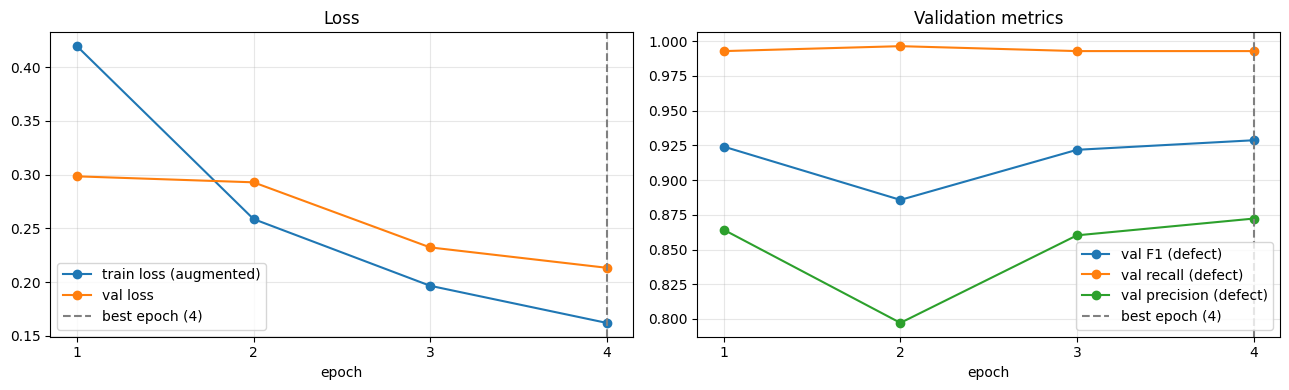

**Training summary:** best epoch **4** with validation defect F1 **0.9287**, recall **0.9929**, precision 0.8723. All 4 epochs ran and validation F1 was still improving at the last epoch, so more epochs may help. Class weights (ok, defect): 1.168, 0.874. MLflow run `ccb03cd91af0447aaf0a10cdbacd714e`.

In [10]:
# TODO 2.3.1-2.3.2: !python -m src.train   (then load artifacts/model_meta.json)
# Runs as a subprocess so it always uses the src/ files written above.
meta_path = Path(config.MODEL_META_PATH)
meta_before = meta_path.stat().st_mtime if meta_path.is_file() else None

# "-u" = unbuffered output, so each epoch line appears as soon as it finishes.
# main() trains, registers the model as @production and saves the drift reference.
run_and_stream([sys.executable, "-u", "-m", "src.train"], "Training: python -m src.train")

if not meta_path.is_file() or meta_path.stat().st_mtime == meta_before:
    raise RuntimeError("model_meta.json was not updated by this training run.")

training_meta = json.loads(meta_path.read_text(encoding="utf-8"))
history = pd.DataFrame(training_meta["history"])
display(history.round(4))

best_epoch = training_meta["best_epoch"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["epoch"], history["train_loss"], "o-", label="train loss (augmented)")
axes[0].plot(history["epoch"], history["val_loss"], "o-", label="val loss")
axes[0].set_title("Loss")
axes[1].plot(history["epoch"], history["val_f1"], "o-", label="val F1 (defect)")
axes[1].plot(history["epoch"], history["val_recall_defect"], "o-", label="val recall (defect)")
axes[1].plot(history["epoch"], history["val_precision_defect"], "o-", label="val precision (defect)")
axes[1].set_title("Validation metrics")
for ax in axes:
    ax.axvline(best_epoch, ls="--", color="gray", label=f"best epoch ({best_epoch})")
    ax.set_xlabel("epoch")
    ax.set_xticks(history["epoch"])
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
curves_path = Path(config.ARTIFACT_DIR) / "training_curves.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()

done = training_meta["epochs_completed"]
requested = training_meta.get("epochs_requested", config.EPOCHS)
if training_meta.get("stopped_early"):
    stop_note = f"Early stopping ended training after {done} of {requested} epochs."
elif best_epoch == done:
    stop_note = (
        f"All {requested} epochs ran and validation F1 was still improving at the "
        "last epoch, so more epochs may help."
    )
else:
    stop_note = f"All {requested} epochs ran; the best epoch was restored."

weights_text = ", ".join(f"{w:.3f}" for w in training_meta["class_weights"])
display(Markdown(
    f"**Training summary:** best epoch **{best_epoch}** with validation defect "
    f"F1 **{training_meta['best_val_f1']:.4f}**, recall "
    f"**{training_meta['best_val_recall_defect']:.4f}**, precision "
    f"{training_meta['best_val_precision_defect']:.4f}. {stop_note} "
    f"Class weights (ok, defect): {weights_text}. "
    f"MLflow run `{training_meta['mlflow_run_id']}`."
))

### 2.3 Training workflow — design

**2.3.1 Loss, optimiser and seed**

- **Class-weighted cross-entropy.** Each class gets the weight w_c = N / (K · n_c), so both classes contribute equally to the loss.
  - On v1 train (2,389 OK / 3,194 defective) this gives about **1.168 for OK and 0.874 for defective**.
  - Here the defective class is the *majority*, so the weighting stops the model from leaning towards the more common class. It does not by itself push towards higher defect recall.
  - Recall is protected by selecting on validation defect F1 and reporting recall as the headline metric. If recall is too low, the next levers are a higher defect weight or a lower decision threshold, both chosen on validation data.
- **Optimiser.** Adam is given `trainable_parameters(model)`, i.e. the head only, with the learning rate and weight decay from `config`.
- **Seed.** Seed 42 (`config.RANDOM_SEED`) is applied to Python, NumPy and PyTorch. The training DataLoader's shuffle uses a seeded generator, and cuDNN runs in deterministic mode.

**2.3.2 Epoch loop, validation and early stopping**

- Each epoch trains on the augmented training split, then evaluates on the un-augmented validation split.
- It records train/val loss plus validation defect F1, precision and recall.
- The best validation-F1 weights are kept. Training stops once F1 has not improved for `config.EARLY_STOP_PATIENCE` epochs, and the best epoch's weights are restored and saved to `artifacts/model.pt`.
- This is the **model-selection step**: it uses validation data only, and the test set is not touched until Stage 3.1.
- Train loss is measured on augmented images, so it can sit above validation loss without any sign of a problem.

**Entry point.** `python -m src.train` runs `main()`, which:

1. trains the model;
2. registers the trained model in MLflow and points the `@production` alias at it (Stage 3.2);
3. saves the Stage 4 drift reference from 300 clean **validation** images: image statistics in `artifacts/reference_features.csv` and 512-d embeddings in `artifacts/reference_embeddings.npz`.

The template's function signatures are kept: `set_seed(seed)`, `class_weights(items)` and `save_reference_baseline(net, ref_items)`. Quality checks and the `v1` split come from Data_Preparation.ipynb, so `main()` only confirms that the split exists instead of re-scanning all 7,348 images.

## **Stage 2.4 — MLflow Experiment Tracking** <font color="red">[6 marks]</font>

- **2.4.1 — Params + per-epoch metrics logged [3]**
- **2.4.2 — Trained model logged to the run [3]**

**Objective:** Track the experiment in MLflow.

**Implement in:** src/train.py (mlflow calls)

**Inputs → Outputs:** training run → MLflow params + per-epoch metrics + logged model

**TODO:** set_experiment; log_params; log_metrics(step=epoch) (2.4.1); log_model (2.4.2).

**Document here:** the runs table (mlflow.search_runs).

In [11]:
# TODO 2.4.1-2.4.2: mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT])
from mlflow import MlflowClient

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
client = MlflowClient()
run_id = training_meta["mlflow_run_id"]

runs = mlflow.search_runs(
    experiment_names=[config.MLFLOW_EXPERIMENT],
    order_by=["start_time DESC"],
)
if runs.empty:
    raise RuntimeError("No MLflow runs found. Run training first.")

columns = [c for c in [
    "run_id", "tags.mlflow.runName", "status", "start_time",
    "params.dataset_version", "params.seed", "params.learning_rate",
    "params.trainable_params", "params.class_weights",
    "metrics.best_epoch", "metrics.best_val_f1", "metrics.best_val_recall_defect",
    "metrics.test_recall_defect",
] if c in runs.columns]
print(f"Runs in experiment '{config.MLFLOW_EXPERIMENT}': {len(runs)}")
display(runs[columns].head(10))

# 2.4.1: parameters and per-epoch metric history of this notebook's run.
run = client.get_run(run_id)
print(f"\nParameters logged for run {run_id}:")
display(pd.DataFrame(sorted(run.data.params.items()), columns=["param", "value"]))

per_epoch = pd.DataFrame({
    key: {m.step: m.value for m in client.get_metric_history(run_id, key)}
    for key in ("train_loss", "val_loss", "val_f1", "val_recall_defect")
})
per_epoch.index.name = "epoch (MLflow step)"
print("Per-epoch metrics read back from MLflow:")
display(per_epoch.round(4))
assert len(per_epoch) == training_meta["epochs_completed"]

# 2.4.2: the trained model logged to the run (an MLflow 3 LoggedModel).
experiment = client.get_experiment_by_name(config.MLFLOW_EXPERIMENT)
run_models = [
    m for m in client.search_logged_models(experiment_ids=[experiment.experiment_id])
    if m.source_run_id == run_id
]
assert run_models, "No logged model was found for this run."
for m in run_models:
    print(f"Logged model: {m.name} | id {m.model_id} | status {m.status}")

model_info = mlflow.models.get_model_info(training_meta["mlflow_model_uri"])
print("Model URI:", training_meta["mlflow_model_uri"])
print("Signature inputs:", model_info.signature.inputs if model_info.signature else None)
print("Signature outputs:", model_info.signature.outputs if model_info.signature else None)
print("Artifacts:", [a.path for a in client.list_artifacts(run_id)])
print("PASS: parameters, per-epoch metrics and the model are logged to MLflow.")

Runs in experiment 'casting_defect_detection': 7


,run_id,tags.mlflow.runName,status,start_time,params.dataset_version,params.seed,params.learning_rate,params.trainable_params,params.class_weights,metrics.best_epoch,metrics.best_val_f1,metrics.best_val_recall_defect,metrics.test_recall_defect
0,ccb03cd91af0447aaf0a10cdbacd714e,resnet18_v1,FINISHED,2026-10-08 14:20:32.506000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",4.0,0.92869,0.992908,NaN
1,0cf6c1199436486692d5e52eb50dde9e,resnet18_v1,FAILED,2026-10-08 13:51:57.221000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",NaN,NaN,NaN,NaN
2,e6b64617f17648dcaf0c8d245cc890a6,resnet18_v1,FINISHED,2026-10-08 11:09:22.655000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",4.0,0.92869,0.992908,NaN
3,89164524b6744bec8af276bcbfdf0807,resnet18_v1,FINISHED,2026-10-08 05:06:01.870000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",4.0,0.92869,0.992908,0.997792
4,effc69afd72c4f45b6f39c26757e6e84,resnet18_v1,FAILED,2026-10-08 04:37:05.590000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",NaN,NaN,NaN,NaN
5,03dc8fbc2e82404aa7c1a4df256d843d,resnet18_v1,RUNNING,2026-10-08 04:04:21.105000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",NaN,NaN,NaN,NaN
6,64349466d27c4c29a4280a7d51f2b6d2,resnet18_v1,FINISHED,2026-10-07 19:30:22.435000+00:00,v1,42,0.001,1026,"[1.1685, 0.874]",4.0,0.92869,0.992908,NaN



Parameters logged for run ccb03cd91af0447aaf0a10cdbacd714e:


,param,value
0,backbone,resnet18
1,batch_size,32
2,class_weights,"[1.1685, 0.874]"
3,dataset_version,v1
4,early_stop_metric,val_f1
5,early_stop_patience,3
6,epochs_requested,4
7,frozen_backbone,True
8,img_size,224
9,learning_rate,0.001


Per-epoch metrics read back from MLflow:


,train_loss,val_loss,val_f1,val_recall_defect
epoch (MLflow step),,,,
1,0.4194,0.2983,0.9241,0.9929
2,0.2586,0.2928,0.8857,0.9965
3,0.1965,0.2322,0.9218,0.9929
4,0.1620,0.2133,0.9287,0.9929


Logged model: casting_defect_model | id m-58cde3d446ee41199f9a3919283d2b37 | status READY
Model URI: models:/m-58cde3d446ee41199f9a3919283d2b37
Signature inputs: [Tensor('float32', (-1, 3, 224, 224))]
Signature outputs: [Tensor('float32', (-1, 2))]
Artifacts: ['checkpoint', 'history.json', 'metadata']
PASS: parameters, per-epoch metrics and the model are logged to MLflow.


### 2.4 MLflow tracking — what is logged

All runs go to the experiment `config.MLFLOW_EXPERIMENT` in the Drive-backed store `config.MLFLOW_TRACKING_URI`. Each training run is named `resnet18_<dataset version>`.

**2.4.1 Parameters and metrics**

- **Parameters:**
  - data: dataset version, seed, image size, train/val sizes and class counts;
  - model: backbone and pretrained weights, frozen flag, total vs trainable parameter counts;
  - training: optimiser, learning rate, weight decay, batch size, requested epochs, early-stopping metric and patience, loss type and class weights.
- **Metrics:** train loss, train F1, val loss, val F1, val precision and val recall are logged **every epoch with `step=epoch`**. That is what produces the curves in the MLflow UI, and the table above reads them back to prove it. Summary metrics (`best_epoch`, `best_val_*`, `epochs_completed`) are logged at the end of the run.

**2.4.2 Model and artifacts**

- The best-epoch model is logged with `mlflow.pytorch.log_model`, together with a signature (float32 image tensor in, two logits out) and an input example.
- In MLflow 3 this creates a *LoggedModel* linked to the run, and Stage 3.2 registers that object.
- The run also stores:
  - the raw checkpoint (`checkpoint/model.pt`);
  - `metadata/model_meta.json` and `history.json`;
  - after Stage 3.1, the test metrics and evaluation plots.

## **Stage 3.1 — Evaluation & Failure Analysis** <font color="red">[7 marks]</font>

- **3.1.1 — Imbalance-aware metrics + model selection [4]**
- **3.1.2 — Confusion/ROC plots + failure-case analysis [3]**

**Objective:** Evaluate on defect recall/F1, not accuracy.

**Implement in:** src/evaluate.py

**Inputs → Outputs:** model + test split → metrics.json + model_eval.png

**TODO:** report recall(defect)/precision/F1/ROC-AUC + select on recall/F1 (3.1.1); plot ROC + confusion and inspect misclassified samples (3.1.2).

**Document here:** the metrics + a short interpretation (why recall matters here).

In [12]:
%%write_module src/evaluate.py --keep-missing
"""Stage 3.1: imbalance-aware test-set evaluation and failure analysis."""
import json
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset

import config
from src import data_prep
from src.model import build_model


class ManifestDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        path, label = self.records[index]
        with Image.open(path) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, int(label)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    device = next(model.parameters()).device
    y_true, y_pred, y_prob_defect = [], [], []

    for images, labels in loader:
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1)

        y_true.extend(labels.numpy().astype(int).tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy().astype(int).tolist())
        y_prob_defect.extend(
            probabilities[:, config.POSITIVE_IDX].cpu().numpy().astype(float).tolist()
        )

    return np.asarray(y_true), np.asarray(y_pred), np.asarray(y_prob_defect)


def compute_metrics(y_true, y_pred, y_prob_defect):
    positive = config.POSITIVE_IDX
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    try:
        roc_auc = float(roc_auc_score(y_true == positive, y_prob_defect))
    except ValueError:
        roc_auc = None

    is_defect = y_true == positive
    predicted_defect = y_pred == positive

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_defect": float(
            precision_score(y_true, y_pred, pos_label=positive, zero_division=0)
        ),
        "recall_defect": float(
            recall_score(y_true, y_pred, pos_label=positive, zero_division=0)
        ),
        "f1_defect": float(f1_score(y_true, y_pred, pos_label=positive, zero_division=0)),
        "roc_auc": roc_auc,
        # Accuracy of a model that calls every casting defective.
        "baseline_accuracy_all_defect": float(is_defect.mean()) if len(y_true) else None,
        "true_positives": int(np.sum(is_defect & predicted_defect)),
        "false_negatives": int(np.sum(is_defect & ~predicted_defect)),
        "false_positives": int(np.sum(~is_defect & predicted_defect)),
        "true_negatives": int(np.sum(~is_defect & ~predicted_defect)),
        "positive_class": config.POSITIVE_CLASS,
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=list(range(config.NUM_CLASSES))
        ).tolist(),
        "confusion_matrix_labels": [
            config.IDX_TO_CLASS[i] for i in range(config.NUM_CLASSES)
        ],
        "selection_metric": "validation defect F1; test set used for final evaluation",
    }


def plot_eval(y_true, y_pred, y_prob_defect, output_path):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=list(range(config.NUM_CLASSES)),
        display_labels=[config.IDX_TO_CLASS[i] for i in range(config.NUM_CLASSES)],
        cmap="Blues",
        values_format="d",
        ax=axes[0],
        colorbar=False,
    )
    axes[0].set_title("Test confusion matrix")

    if len(np.unique(y_true)) == 2:
        RocCurveDisplay.from_predictions(
            (np.asarray(y_true) == config.POSITIVE_IDX).astype(int),
            y_prob_defect,
            name="Defect",
            ax=axes[1],
        )
        axes[1].plot([0, 1], [0, 1], "--", color="gray")
        axes[1].set_title("Test ROC curve")
    else:
        axes[1].text(0.5, 0.5, "ROC unavailable: test set has one class",
                     ha="center", va="center")
        axes[1].set_axis_off()

    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return output_path


def failure_cases(records, y_true, y_pred, y_prob_defect, limit=20):
    """Misclassified samples, most confident mistakes first (limit=None: all)."""
    errors = []
    for i in np.flatnonzero(np.asarray(y_true) != np.asarray(y_pred)):
        true_label = int(y_true[i])
        pred_label = int(y_pred[i])
        errors.append({
            "path": str(records[i][0]),
            "true_label": config.IDX_TO_CLASS[true_label],
            "predicted_label": config.IDX_TO_CLASS[pred_label],
            "prob_defect": float(y_prob_defect[i]),
            "error_type": (
                "false_negative" if true_label == config.POSITIVE_IDX else "false_positive"
            ),
        })

    errors.sort(key=lambda row: abs(row["prob_defect"] - 0.5), reverse=True)
    return errors if limit is None else errors[:limit]


def evaluate_test_set(version="v1"):
    root = data_prep.find_data_root()
    records = data_prep.load_split(version, "test", root)

    if not records:
        raise ValueError("The test manifest is empty.")
    if not Path(config.MODEL_PATH).is_file():
        raise FileNotFoundError(f"Checkpoint not found: {config.MODEL_PATH}")

    device_name = config.DEVICE
    if device_name != "cpu" and not torch.cuda.is_available():
        device_name = "cpu"
    device = torch.device(device_name)

    model = build_model(pretrained=False).to(device)
    state = torch.load(config.MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(state)

    loader = DataLoader(
        ManifestDataset(records, data_prep.get_transforms(train=False)),
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
    )

    y_true, y_pred, y_prob_defect = predict(model, loader)
    metrics = compute_metrics(y_true, y_pred, y_prob_defect)
    metrics["dataset_version"] = version
    metrics["test_images"] = len(records)

    # Link the results to the training run that produced the checkpoint.
    meta_path = Path(config.MODEL_META_PATH)
    if meta_path.is_file():
        training_meta = json.loads(meta_path.read_text(encoding="utf-8"))
        metrics["mlflow_run_id"] = training_meta.get("mlflow_run_id")

    cases = failure_cases(records, y_true, y_pred, y_prob_defect, limit=None)
    metrics["misclassified"] = len(cases)

    Path(config.ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)
    Path(config.METRICS_PATH).write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    plot_eval(y_true, y_pred, y_prob_defect, Path(config.ARTIFACT_DIR) / "model_eval.png")

    failure_path = Path(config.ARTIFACT_DIR) / "failure_cases.json"
    failure_path.write_text(json.dumps(cases, indent=2), encoding="utf-8")

    return metrics, cases


if __name__ == "__main__":
    metrics, cases = evaluate_test_set()
    print(json.dumps(metrics, indent=2))
    print(
        f"Misclassified: {len(cases)} "
        f"(false negatives: {metrics['false_negatives']}, "
        f"false positives: {metrics['false_positives']})"
    )
    print("Metrics:", config.METRICS_PATH)
    print("Plot:", Path(config.ARTIFACT_DIR) / "model_eval.png")

src/evaluate.py already up to date


--- Test evaluation: python -m src.evaluate ---
{
  "accuracy": 0.9370629370629371,
  "precision_defect": 0.9112903225806451,
  "recall_defect": 0.9977924944812362,
  "f1_defect": 0.9525816649104321,
  "roc_auc": 0.9966381881603559,
  "baseline_accuracy_all_defect": 0.6335664335664336,
  "true_positives": 452,
  "false_negatives": 1,
  "false_positives": 44,
  "true_negatives": 218,
  "positive_class": "def_front",
  "confusion_matrix": [
    [
      218,
      44
    ],
    [
      1,
      452
    ]
  ],
  "confusion_matrix_labels": [
    "ok_front",
    "def_front"
  ],
  "selection_metric": "validation defect F1; test set used for final evaluation",
  "dataset_version": "v1",
  "test_images": 715,
  "mlflow_run_id": "ccb03cd91af0447aaf0a10cdbacd714e",
  "misclassified": 45
}
Misclassified: 45 (false negatives: 1, false positives: 44)
Metrics: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/metrics.json
Plot: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifa

,value
metric,
Recall (defect) — headline,0.9978
Precision (defect),0.9113
F1 (defect),0.9526
ROC-AUC,0.9966
Accuracy,0.9371
Accuracy if everything is called defective,0.6336


,pred ok_front,pred def_front
true ok_front,218,44
true def_front,1,452


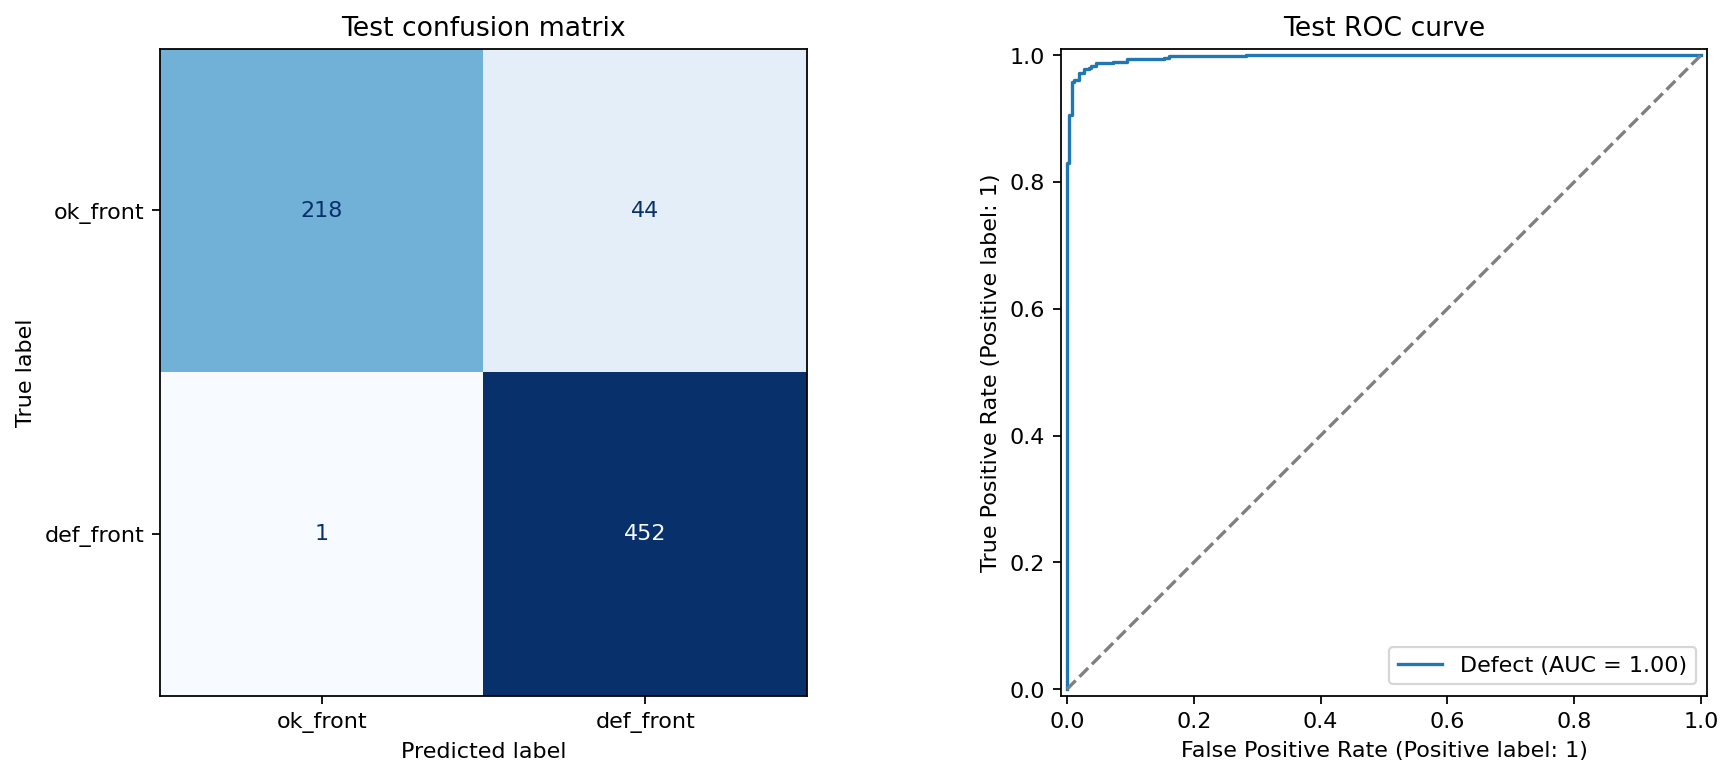

Misclassified test images: {'false_positive': 44, 'false_negative': 1}


,file,true_label,predicted_label,prob_defect,error_type
0,cast_ok_0_1121.jpeg,ok_front,def_front,0.9403,false_positive
1,cast_ok_0_7839.jpeg,ok_front,def_front,0.8941,false_positive
2,cast_ok_0_960.jpeg,ok_front,def_front,0.8076,false_positive
3,cast_ok_0_16.jpeg,ok_front,def_front,0.8018,false_positive
4,cast_ok_0_6718.jpeg,ok_front,def_front,0.8004,false_positive
5,cast_ok_0_2707.jpeg,ok_front,def_front,0.7705,false_positive
6,cast_ok_0_2330.jpeg,ok_front,def_front,0.7697,false_positive
7,cast_ok_0_9955.jpeg,ok_front,def_front,0.7333,false_positive
8,cast_ok_0_1210.jpeg,ok_front,def_front,0.7291,false_positive
9,cast_ok_0_9926.jpeg,ok_front,def_front,0.7226,false_positive


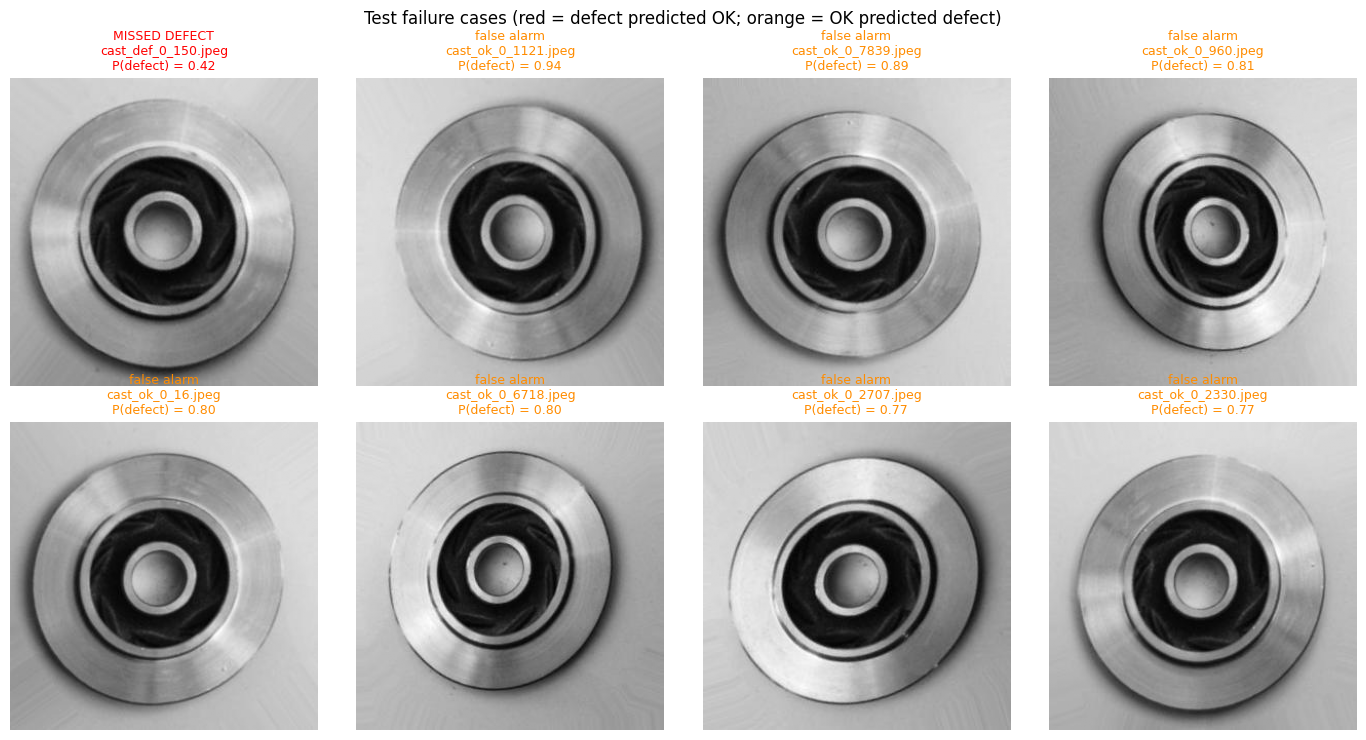

Test metrics and plots logged to MLflow run ccb03cd91af0447aaf0a10cdbacd714e


**Test set:** 715 images (453 defective, 262 OK).
- **Defect recall 0.998:** 452 of 453 defective castings were caught; **1 were missed** (false negatives, which would ship).
- **Precision 0.911:** 44 of 262 good castings were flagged for unnecessary re-inspection (false positives).
- **F1 0.953; ROC-AUC 0.997** (threshold-independent ranking quality).
- Accuracy 0.937 compares with 0.634 for a model that calls everything defective, so accuracy alone says little here.
- To cut the 1 missed defects, the decision threshold could be lowered below 0.5, trading more false alarms for higher recall. That threshold must be chosen on **validation** data, not on this test set.

In [13]:
# TODO 3.1.1-3.1.2: load artifacts/metrics.json + show artifacts/model_eval.png
from mlflow import MlflowClient
from PIL import Image

metrics_path = Path(config.METRICS_PATH)
metrics_before = metrics_path.stat().st_mtime if metrics_path.is_file() else None

run_and_stream([sys.executable, "-u", "-m", "src.evaluate"], "Test evaluation: python -m src.evaluate")

artifact_dir = Path(config.ARTIFACT_DIR)
plot_path = artifact_dir / "model_eval.png"
failures_path = artifact_dir / "failure_cases.json"
if not metrics_path.is_file() or metrics_path.stat().st_mtime == metrics_before:
    raise RuntimeError("metrics.json was not updated by this evaluation.")

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
failures = json.loads(failures_path.read_text(encoding="utf-8"))
training_meta = json.loads(Path(config.MODEL_META_PATH).read_text(encoding="utf-8"))
if metrics.get("mlflow_run_id") != training_meta["mlflow_run_id"]:
    raise ValueError("metrics.json and model_meta.json refer to different training runs.")

# 3.1.1: imbalance-aware metrics (defect = positive class).
display(pd.DataFrame([
    {"metric": "Recall (defect) — headline", "value": metrics["recall_defect"]},
    {"metric": "Precision (defect)", "value": metrics["precision_defect"]},
    {"metric": "F1 (defect)", "value": metrics["f1_defect"]},
    {"metric": "ROC-AUC", "value": metrics["roc_auc"]},
    {"metric": "Accuracy", "value": metrics["accuracy"]},
    {"metric": "Accuracy if everything is called defective",
     "value": metrics["baseline_accuracy_all_defect"]},
]).set_index("metric").round(4))

labels = metrics["confusion_matrix_labels"]
display(pd.DataFrame(
    metrics["confusion_matrix"],
    index=[f"true {n}" for n in labels],
    columns=[f"pred {n}" for n in labels],
))

# 3.1.2: confusion matrix + ROC curve.
display(DisplayImage(filename=str(plot_path)))

# 3.1.2: failure cases — missed defects first, most confident mistakes first.
failure_grid_path = artifact_dir / "failure_cases.png"
fail_df = pd.DataFrame(failures)
if fail_df.empty:
    print("No misclassified test images.")
else:
    print("Misclassified test images:", fail_df["error_type"].value_counts().to_dict())
    fail_df["file"] = fail_df["path"].map(lambda p: Path(p).name)
    display(fail_df[["file", "true_label", "predicted_label", "prob_defect",
                     "error_type"]].head(15).round(4))

    ordered = pd.concat([
        fail_df[fail_df["error_type"] == "false_negative"],
        fail_df[fail_df["error_type"] == "false_positive"],
    ]).head(8)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, row) in zip(axes.flat, ordered.iterrows()):
        with Image.open(row["path"]) as image:
            ax.imshow(image.convert("L"), cmap="gray", vmin=0, vmax=255)
        missed = row["error_type"] == "false_negative"
        ax.set_title(
            f"{'MISSED DEFECT' if missed else 'false alarm'}\n"
            f"{row['file']}\nP(defect) = {row['prob_defect']:.2f}",
            color="red" if missed else "darkorange", fontsize=9,
        )
    fig.suptitle("Test failure cases (red = defect predicted OK; orange = OK predicted defect)")
    plt.tight_layout()
    fig.savefig(failure_grid_path, dpi=130, bbox_inches="tight")
    plt.show()

# Attach test results to the training run so MLflow holds the full story.
client = MlflowClient(tracking_uri=config.MLFLOW_TRACKING_URI)
run_id = training_meta["mlflow_run_id"]
for key in ("recall_defect", "precision_defect", "f1_defect", "roc_auc", "accuracy"):
    if metrics.get(key) is not None:
        client.log_metric(run_id, f"test_{key}", float(metrics[key]))
for path in (metrics_path, plot_path, failures_path, failure_grid_path,
             artifact_dir / "training_curves.png"):
    if path.is_file():
        client.log_artifact(run_id, str(path), artifact_path="evaluation")
print("Test metrics and plots logged to MLflow run", run_id)

# Interpretation generated from the actual numbers.
tp, fn = metrics["true_positives"], metrics["false_negatives"]
fp, tn = metrics["false_positives"], metrics["true_negatives"]
lines = [
    f"**Test set:** {metrics['test_images']} images ({tp + fn} defective, {tn + fp} OK).",
    f"- **Defect recall {metrics['recall_defect']:.3f}:** {tp} of {tp + fn} defective "
    f"castings were caught; **{fn} were missed** (false negatives, which would ship).",
    f"- **Precision {metrics['precision_defect']:.3f}:** {fp} of {tn + fp} good castings "
    "were flagged for unnecessary re-inspection (false positives).",
    f"- **F1 {metrics['f1_defect']:.3f}; ROC-AUC "
    + (f"{metrics['roc_auc']:.3f}" if metrics["roc_auc"] is not None else "n/a")
    + "** (threshold-independent ranking quality).",
    f"- Accuracy {metrics['accuracy']:.3f} compares with "
    f"{metrics['baseline_accuracy_all_defect']:.3f} for a model that calls everything "
    "defective, so accuracy alone says little here.",
]
if tp + fp == 0 or tn + fn == 0:
    lines.append(
        "- ⚠️ **The model predicts only one class on the test set.** It has not learned "
        "to separate the classes. Check the data version, epochs and learning rate "
        "before registering it."
    )
elif fn > 0:
    lines.append(
        f"- To cut the {fn} missed defects, the decision threshold could be lowered "
        "below 0.5, trading more false alarms for higher recall. That threshold must be "
        "chosen on **validation** data, not on this test set."
    )
display(Markdown("\n".join(lines)))

### 3.1 Evaluation — why these metrics, and how the model was selected

- **Why recall on defects is the headline metric.** A **false negative** is a defective casting labelled OK. It ships to a customer and can cause a pump failure, a warranty claim or a safety incident. A **false positive** only sends a good part for a manual re-check. The costs are very unequal, so recall on `def_front` comes first. Precision and F1 show what that recall costs in false alarms.
- **Why not accuracy.** Defects are 63% of the test set, so a model that flags everything gets about 63% accuracy while being useless. The summary above prints that baseline next to the real accuracy.
- **ROC-AUC** measures how well the model *ranks* defective above OK images across all thresholds. That makes it the right number for deciding whether moving the 0.5 threshold could buy more recall.
- **Model selection (3.1.1).**
  - The checkpoint was chosen *during training* as the epoch with the best **validation defect F1** (Stage 2.3).
  - The test set is used **once**, here, as an unbiased final estimate. Nothing is tuned on it.
  - Because the 64 duplicate images were removed in Data Preparation, no test image was seen during training.
- **Failure analysis (3.1.2).** The grid shows the most confident mistakes, with missed defects first. When reading it, check:
  - whether missed defects are small or low-contrast (e.g. pinholes near the rim), which the 300 → 224 resize may weaken;
  - whether false alarms share a lighting or brightness pattern, which would link back to the brightness difference found in the Stage 1.4 EDA;
  - whether any images look mislabelled.

## **Stage 3.2 — Model Registry & Promotion** <font color="red">[5 marks]</font>

- **3.2.1 — Best model registered in MLflow Registry [2]**
- **3.2.2 — Promotion to production alias + version history [3]**

**Objective:** Register and promote the best model.

**Implement in:** src/train.py (MLflow registry)

**Inputs → Outputs:** best run → registered model + @production alias

**TODO:** register_model(casting_defect_classifier) (3.2.1); set_registered_model_alias('production', v) with version history (3.2.2).

**Document here:** the registry version + alias (screenshot the MLflow Models page).

In [14]:
# TODO 3.2.1-3.2.2: MlflowClient().get_model_version_by_alias(config.REGISTERED_MODEL, 'production')
from mlflow import MlflowClient
from src import train as train_module

importlib.reload(train_module)
result = train_module.register_and_promote()

client = MlflowClient(tracking_uri=config.MLFLOW_TRACKING_URI)
production = client.get_model_version_by_alias(config.REGISTERED_MODEL, "production")
training_meta = json.loads(Path(config.MODEL_META_PATH).read_text(encoding="utf-8"))

assert str(production.version) == result["version"]
assert production.run_id == training_meta["mlflow_run_id"] == result["run_id"]

print("Registered model:", result["name"])
print("Production version:", production.version,
      "(new version)" if result["created_new_version"] else "(run already registered; version reused)")
print("Previously @production:", result["previous_version"])
print("Source run:", production.run_id)
print("Version tags:", production.tags)
print("Description:", production.description)

versions = client.search_model_versions(f"name='{config.REGISTERED_MODEL}'")
history_df = pd.DataFrame([
    {
        "version": int(v.version),
        "created": pd.to_datetime(v.creation_timestamp, unit="ms"),
        "run_id": v.run_id,
        "status": v.status,
        "aliases": ", ".join(v.aliases or []),
        "val_f1": v.tags.get("best_val_f1"),
        "test_recall_defect": v.tags.get("test_recall_defect"),
    }
    for v in versions
]).sort_values("version")
print("\nVersion history:")
display(history_df)

display(Markdown(
    f"**Registry:** `{result['name']}` **version {production.version}** carries the "
    f"`@production` alias (source run `{production.run_id}`). "
    f"{len(history_df)} version(s) are kept in the history, so rolling back means moving "
    "the alias to an older version with `client.set_registered_model_alias(name, "
    "'production', <version>)`."
))

Note: version description stored as a tag (RepresenterError).
Registered model: casting_defect_classifier
Production version: 4 (run already registered; version reused)
Previously @production: 4
Source run: ccb03cd91af0447aaf0a10cdbacd714e
Version tags: {'dataset_version': 'v1', 'selection_metric': 'best validation defect F1 (early stopping)', 'best_epoch': '4', 'best_val_f1': '0.9287', 'best_val_recall_defect': '0.9929', 'description': 'ResNet18 (frozen ImageNet backbone, 2-class head) trained on dataset v1; selected at epoch 4 by validation defect F1 0.9287.', 'test_recall_defect': '0.9978', 'test_precision_defect': '0.9113', 'test_f1_defect': '0.9526', 'test_roc_auc': '0.9966'}
Description: None

Version history:


,version,created,run_id,status,aliases,val_f1,test_recall_defect
3,1,2026-10-07 20:45:25.855,64349466d27c4c29a4280a7d51f2b6d2,READY,,0.9287,None
2,2,2026-10-08 05:34:51.222,89164524b6744bec8af276bcbfdf0807,READY,,0.9287,0.9978
1,3,2026-10-08 12:11:23.584,e6b64617f17648dcaf0c8d245cc890a6,READY,,0.9287,None
0,4,2026-10-08 15:19:44.343,ccb03cd91af0447aaf0a10cdbacd714e,READY,production,0.9287,0.9978


**Registry:** `casting_defect_classifier` **version 4** carries the `@production` alias (source run `ccb03cd91af0447aaf0a10cdbacd714e`). 4 version(s) are kept in the history, so rolling back means moving the alias to an older version with `client.set_registered_model_alias(name, 'production', <version>)`.

In [15]:
# Optional: open the MLflow UI inside Colab for the Models-page screenshot.
# Save the screenshot as mlflow_models_page.png and upload it in the next cell.
MLFLOW_PORT = 5000

if "mlflow_ui" not in globals() or mlflow_ui.poll() is not None:
    mlflow_ui = subprocess.Popen(
        [sys.executable, "-m", "mlflow", "ui",
         "--backend-store-uri", config.MLFLOW_TRACKING_URI,
         "--port", str(MLFLOW_PORT)],
        cwd=PROJECT_DIR, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
    time.sleep(10)

if mlflow_ui.poll() is not None:
    raise RuntimeError("The MLflow UI did not start.")

try:
    from google.colab import output
    output.serve_kernel_port_as_window(MLFLOW_PORT, path="/#/models")
except ImportError:
    print(f"Open http://localhost:{MLFLOW_PORT}/#/models")

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

MLflow Models page (registry version + @production): /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/submission/evidence/mlflow_models_page.png


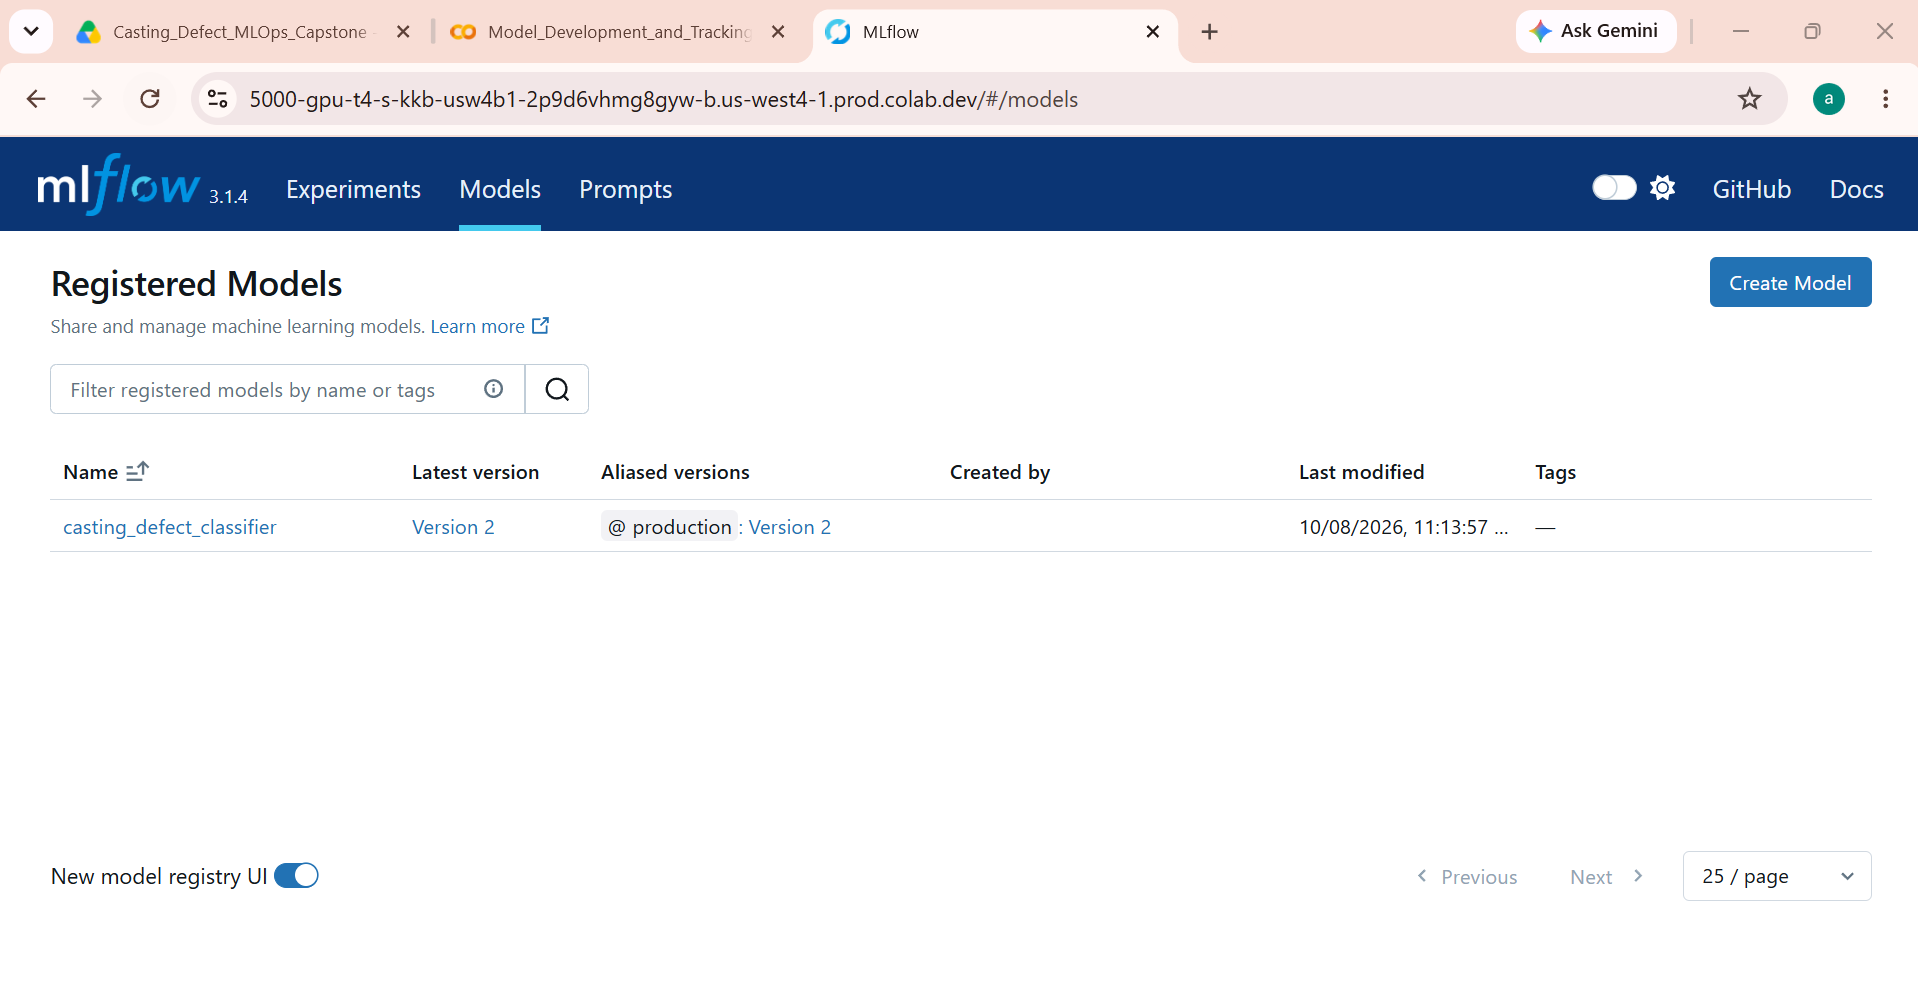

True

In [16]:
UPLOAD_SCREENSHOT = False # set True once, to upload mlflow_models_page.png
if UPLOAD_SCREENSHOT:
    upload_evidence(["mlflow_models_page.png"])

show_evidence("mlflow_models_page.png", "MLflow Models page (registry version + @production)")

### 3.2 Registry and promotion — how it works

**3.2.1 Registration**

- `register_and_promote()` in `src/train.py` takes the run recorded in `model_meta.json`. That is the run whose weights are in `artifacts/model.pt`, which the API serves.
- It finds that run's logged model and registers it as **`casting_defect_classifier`**.
- Re-running it does not create duplicates: a run that is already registered reuses its version.
- `main()` in `src/train.py` already registers the model at the end of training. Running the cell above after Stage 3.1 therefore reuses that version and adds the test-metric tags to it.

**3.2.2 Promotion and version history**

- The `production` **alias** is moved to the new version. Aliases replace the deprecated "Staging/Production" stages in recent MLflow versions.
- Each version gets **tags** recording why it was promoted (validation F1 and recall, best epoch, dataset version and, once Stage 3.1 has run, the test metrics) plus a description.
- **Older versions stay in the registry**, so the table above is the version history. Rolling back is a single alias change, with no retraining needed.
- The history is also saved to `artifacts/model_registry_history.json`.

**Current design choice:** each new training run is promoted. A stricter gate would only move the alias when the new version's validation defect F1 or recall beats the current production version.

## **Stage 3.3 — FastAPI Inference Service** <font color="red">[6 marks]</font>

- **3.3.1 — Image /predict + /health + logging + validation [4]** — *to be done in app.py*
- **3.3.2 — Live call demonstrated in-notebook [2]** — *to be done in this notebook*

**Objective:** Serve the model behind an image API and demonstrate it.

**Implement in:** app.py (+ a TestClient demo here)

**Inputs → Outputs:** image upload → {label, prob_defect, confidence}; /health; predictions logged

**TODO:** implement /health + POST /predict (UploadFile) with validation (bad image 400, no-model 503) + logging (3.3.1, in app.py); demo with TestClient on a sample image (3.3.2, here).

**Document here:** the live request/response (TestClient output).

In [17]:
# Writes the complete app.py (Stage 3.3.1) directly. A backup of the old file is kept.
import shutil
import time
from pathlib import Path

APP_SOURCE = r'''"""app.py — Stage 3: FastAPI inference service.

Implement /health (liveness + loaded model info) and POST /predict (multipart image upload
→ {label, prob_defect, confidence}). Load the model once at startup; log every prediction
to artifacts/predictions.log.   Run: uvicorn app:app --host 0.0.0.0 --port 8000
"""
from __future__ import annotations

import io, json, time
import logging
from contextlib import asynccontextmanager
from pathlib import Path

import torch, torch.nn.functional as F
from fastapi import FastAPI, File, UploadFile, HTTPException
from PIL import Image, UnidentifiedImageError

import config
from src import data_prep
from src.model import load_model

_state = {"model": None, "tf": None, "meta": {}}

logger = logging.getLogger("casting_api")
logger.setLevel(logging.INFO)

PREDICTION_LOG = Path(config.ARTIFACT_DIR) / "predictions.log"
MAX_UPLOAD_BYTES = 10 * 1024 * 1024  # 10 MB


def _read_json(path) -> dict:
    path = Path(path)
    if not path.is_file():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except (OSError, ValueError) as error:
        logger.warning("Could not read %s: %s", path, error)
        return {}


def _load():
    """Load model + eval transforms + model_meta.json once, if a checkpoint exists.

    Never raises: without a checkpoint (e.g. in CI) the API still starts, /health
    reports model_loaded=false and /predict answers 503.
    """
    _state.update({"model": None, "tf": None, "meta": {}})
    model_path = Path(config.MODEL_PATH)

    if not model_path.is_file():
        logger.warning("No model checkpoint at %s; /predict will return 503.", model_path)
        return

    try:
        model = load_model(model_path)
        model.eval()
        _state["tf"] = data_prep.get_transforms(train=False)
        _state["meta"] = _read_json(config.MODEL_META_PATH)
        _state["model"] = model
        logger.info(
            "Model loaded from %s (version %s).",
            model_path, _state["meta"].get("model_version", "unregistered"),
        )
    except Exception:
        logger.exception("Failed to load the model; /predict will return 503.")
        _state.update({"model": None, "tf": None})


@asynccontextmanager
async def lifespan(app: FastAPI):
    _load(); yield


app = FastAPI(title="Casting Defect Detection API", version="1.0", lifespan=lifespan)


@app.get("/health")
def health() -> dict:
    """Liveness + information about the loaded model."""
    meta = _state["meta"]
    metrics = _read_json(config.METRICS_PATH)
    test_metrics = {
        key: metrics[key]
        for key in ("recall_defect", "precision_defect", "f1_defect", "roc_auc", "accuracy")
        if key in metrics
    } or None

    return {
        "status": "ok",
        "model_loaded": _state["model"] is not None,
        "classes": config.CLASS_TO_IDX,
        "positive_class": config.POSITIVE_CLASS,
        "model_version": meta.get("model_version"),
        "registered_model": meta.get("registered_model"),
        "mlflow_run_id": meta.get("mlflow_run_id"),
        "test_metrics": test_metrics,
    }


def _log_prediction(record: dict) -> None:
    """Append one JSON line to artifacts/predictions.log and to the app logger."""
    logger.info("prediction %s", json.dumps(record))
    try:
        PREDICTION_LOG.parent.mkdir(parents=True, exist_ok=True)
        with PREDICTION_LOG.open("a", encoding="utf-8") as log_file:
            log_file.write(json.dumps(record) + "\n")
    except OSError as error:
        logger.warning("Could not write prediction log: %s", error)


@app.post("/predict")
async def predict(file: UploadFile = File(...)) -> dict:
    """Classify one uploaded casting image."""
    started = time.perf_counter()
    model, transform = _state["model"], _state["tf"]

    # 503: the service is up but has no model to serve.
    if model is None or transform is None:
        raise HTTPException(status_code=503, detail="Model not loaded. Train a model first.")

    # 400: empty, oversized or undecodable uploads.
    data = await file.read()
    if not data:
        raise HTTPException(status_code=400, detail="Empty upload.")
    if len(data) > MAX_UPLOAD_BYTES:
        raise HTTPException(status_code=400, detail="File too large (limit 10 MB).")
    try:
        with Image.open(io.BytesIO(data)) as image:
            image.load()  # fully decode: catches truncated/corrupt files
            image = image.convert("RGB")
    except (UnidentifiedImageError, OSError, ValueError, Image.DecompressionBombError):
        logger.info("Rejected upload %r: not a valid image.", file.filename)
        raise HTTPException(status_code=400, detail="Upload must be a valid image file.")

    # Same preprocessing as validation/test: grayscale x3, resize, ImageNet normalisation.
    device = next(model.parameters()).device
    batch = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probabilities = F.softmax(model(batch), dim=1)[0].tolist()

    predicted_idx = max(range(len(probabilities)), key=probabilities.__getitem__)
    label = config.IDX_TO_CLASS[predicted_idx]
    prob_defect = float(probabilities[config.POSITIVE_IDX])
    result = {
        "label": label,
        "is_defective": predicted_idx == config.POSITIVE_IDX,
        "prob_defect": round(prob_defect, 6),
        "confidence": round(float(probabilities[predicted_idx]), 6),
    }

    _log_prediction({
        "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        "filename": file.filename,
        "model_version": _state["meta"].get("model_version"),
        "latency_ms": round((time.perf_counter() - started) * 1000, 2),
        **result,
    })
    return result'''

PROJECT_DIR = Path("/content/drive/MyDrive/Casting_Defect_MLOps_Capstone")
app_path = PROJECT_DIR / "app.py"

compile(APP_SOURCE, str(app_path), "exec")  # stop here if anything is broken

backup_dir = PROJECT_DIR / "artifacts" / "backups" / "src"
backup_dir.mkdir(parents=True, exist_ok=True)
if app_path.is_file():
    backup = backup_dir / f"app_template_{time.strftime('%Y%m%d_%H%M%S')}.py"
    shutil.copy2(app_path, backup)
    print("Backup of old file:", backup)

app_path.write_text(APP_SOURCE + "\n", encoding="utf-8")
written = app_path.read_text(encoding="utf-8")
print(len(written.splitlines()), "lines written to", app_path)
print("TEMPLATE - still not implemented" if "raise NotImplementedError" in written
      else "OK - app.py implemented")

Backup of old file: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/backups/src/app_template_20261008_152814.py
159 lines written to /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/app.py
OK - app.py implemented


In [18]:
# 3.3.1 evidence: show app.py and check that the required pieces are present.
import re

app_source = (PROJECT_DIR / "app.py").read_text(encoding="utf-8")
print(app_source)

# Check the code itself, not comments, so TODO text cannot count as "found".
code_only = "\n".join(line.split("#", 1)[0] for line in app_source.splitlines())

app_checks = {
    "GET /health route": r"\.get\(\s*['\"]/health",
    "POST /predict route": r"\.post\(\s*['\"]/predict",
    "UploadFile input": r"UploadFile",
    "HTTP 400 for bad input": r"status_code\s*=\s*400",
    "HTTP 503 when no model": r"status_code\s*=\s*503",
    "logging of predictions": r"logger\.info\(\s*\"prediction",
    "prediction log file": r"predictions\.log",
    "no TODO stubs left": None,
}
display(pd.DataFrame([
    {
        "requirement": name,
        "found in app.py": ("NotImplementedError" not in code_only) if pattern is None
        else bool(re.search(pattern, code_only)),
    }
    for name, pattern in app_checks.items()
]))

"""app.py — Stage 3: FastAPI inference service.

Implement /health (liveness + loaded model info) and POST /predict (multipart image upload
→ {label, prob_defect, confidence}). Load the model once at startup; log every prediction
to artifacts/predictions.log.   Run: uvicorn app:app --host 0.0.0.0 --port 8000
"""
from __future__ import annotations

import io, json, time
import logging
from contextlib import asynccontextmanager
from pathlib import Path

import torch, torch.nn.functional as F
from fastapi import FastAPI, File, UploadFile, HTTPException
from PIL import Image, UnidentifiedImageError

import config
from src import data_prep
from src.model import load_model

_state = {"model": None, "tf": None, "meta": {}}

logger = logging.getLogger("casting_api")
logger.setLevel(logging.INFO)

PREDICTION_LOG = Path(config.ARTIFACT_DIR) / "predictions.log"
MAX_UPLOAD_BYTES = 10 * 1024 * 1024  # 10 MB


def _read_json(path) -> dict:
    path = Path(path)
    if not path.is_file():
        ret

,requirement,found in app.py
0,GET /health route,True
1,POST /predict route,True
2,UploadFile input,True
3,HTTP 400 for bad input,True
4,HTTP 503 when no model,True
5,logging of predictions,True
6,prediction log file,True
7,no TODO stubs left,True


INFO:casting_api:Model loaded from /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/model.pt (version 4).
INFO:httpx:HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
INFO:casting_api:prediction {"timestamp": "2026-10-08T15:28:51+0000", "filename": "cast_ok_0_10.jpeg", "model_version": "4", "latency_ms": 113.66, "label": "ok_front", "is_defective": false, "prob_defect": 0.428766, "confidence": 0.571234}


GET /health -> 200
{
  "status": "ok",
  "model_loaded": true,
  "classes": {
    "ok_front": 0,
    "def_front": 1
  },
  "positive_class": "def_front",
  "model_version": "4",
  "registered_model": "casting_defect_classifier",
  "mlflow_run_id": "ccb03cd91af0447aaf0a10cdbacd714e",
  "test_metrics": {
    "recall_defect": 0.9977924944812362,
    "precision_defect": 0.9112903225806451,
    "f1_defect": 0.9525816649104321,
    "roc_auc": 0.9966381881603559,
    "accuracy": 0.9370629370629371
  }
}


INFO:httpx:HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
INFO:casting_api:prediction {"timestamp": "2026-10-08T15:28:51+0000", "filename": "cast_def_0_1059.jpeg", "model_version": "4", "latency_ms": 110.68, "label": "def_front", "is_defective": true, "prob_defect": 0.850093, "confidence": 0.850093}
INFO:httpx:HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"



POST /predict  cast_ok_0_10.jpeg (true: ok_front) -> 200
{'label': 'ok_front', 'is_defective': False, 'prob_defect': 0.428766, 'confidence': 0.571234}

POST /predict  cast_def_0_1059.jpeg (true: def_front) -> 200
{'label': 'def_front', 'is_defective': True, 'prob_defect': 0.850093, 'confidence': 0.850093}


INFO:casting_api:Rejected upload 'not_an_image.txt': not a valid image.
INFO:httpx:HTTP Request: POST http://testserver/predict "HTTP/1.1 400 Bad Request"
INFO:casting_api:Rejected upload 'broken.jpg': not a valid image.
INFO:httpx:HTTP Request: POST http://testserver/predict "HTTP/1.1 400 Bad Request"



POST /predict  text file -> 400 {'detail': 'Upload must be a valid image file.'}
POST /predict  corrupt JPEG -> 400 {"detail":"Upload must be a valid image file."}
Corrupt-image handling: PASS (400)

App log records captured:
INFO casting_api: Model loaded from /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/artifacts/model.pt (version 4).
INFO casting_api: prediction {"timestamp": "2026-10-08T15:28:51+0000", "filename": "cast_ok_0_10.jpeg", "model_version": "4", "latency_ms": 113.66, "label": "ok_front", "is_defective": false, "prob_defect": 0.428766, "confidence": 0.571234}
INFO casting_api: prediction {"timestamp": "2026-10-08T15:28:51+0000", "filename": "cast_def_0_1059.jpeg", "model_version": "4", "latency_ms": 110.68, "label": "def_front", "is_defective": true, "prob_defect": 0.850093, "confidence": 0.850093}
INFO casting_api: Rejected upload 'not_an_image.txt': not a valid image.
INFO casting_api: Rejected upload 'broken.jpg': not a valid image.


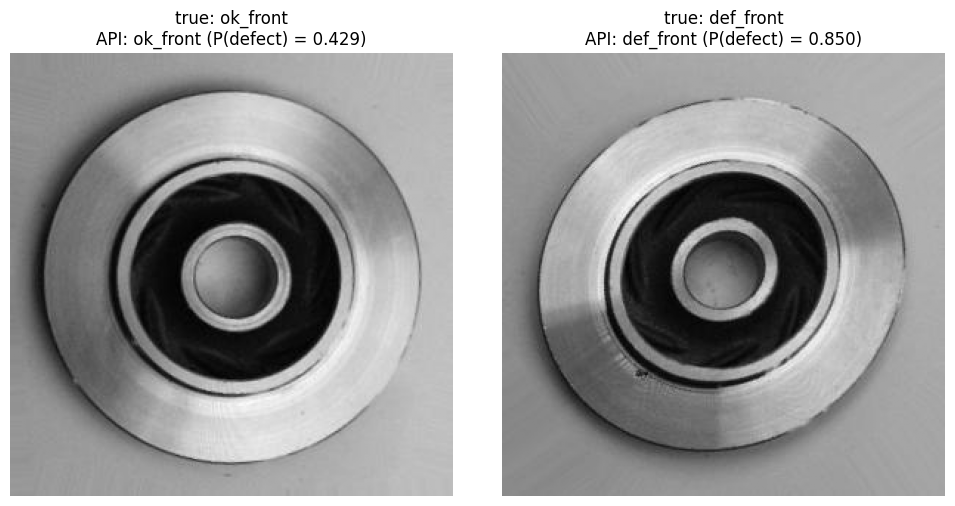

**Stage 3.3 evidence:** `/health` returned 200 with the model loaded. `/predict` on `cast_ok_0_10.jpeg` (true `ok_front`) returned `ok_front` with P(defect) = 0.4288. `/predict` on `cast_def_0_1059.jpeg` (true `def_front`) returned `def_front` with P(defect) = 0.8501. A non-image upload returned 400 and a corrupt JPEG returned 400.

In [19]:
# TODO 3.3.2: with TestClient(app.app) as c: call /health and POST a sample image to /predict
import logging
import mimetypes

from fastapi.testclient import TestClient
from PIL import Image

if "raise NotImplementedError" in (PROJECT_DIR / "app.py").read_text(encoding="utf-8"):
    raise RuntimeError("app.py is still the template. Run the 'Writes the complete app.py' cell first.")

import app as api

importlib.reload(api)  # pick up the new app.py and the latest model.pt / model_meta.json

# One OK and one defective image from the held-out test split.
test_records = data_prep.load_split(DATA_VERSION, "test", root)
samples = [
    next(path for path, label in test_records if label == config.CLASS_TO_IDX[name])
    for name in config.CLASS_TO_IDX
]


class _ListHandler(logging.Handler):
    def __init__(self):
        super().__init__()
        self.records = []

    def emit(self, record):
        self.records.append(record)


captured = _ListHandler()
root_logger = logging.getLogger()
previous_level = root_logger.level
root_logger.addHandler(captured)
root_logger.setLevel(logging.INFO)

results = []
try:
    with TestClient(api.app) as client:
        health = client.get("/health")
        print("GET /health ->", health.status_code)
        print(json.dumps(health.json(), indent=2))
        assert health.status_code == 200
        assert health.json().get("model_loaded") is True

        for path in samples:
            content_type = mimetypes.guess_type(path.name)[0] or "image/jpeg"
            with path.open("rb") as image_file:
                response = client.post(
                    "/predict", files={"file": (path.name, image_file, content_type)}
                )
            body = response.json()
            print(f"\nPOST /predict  {path.name} (true: {path.parent.name}) ->",
                  response.status_code)
            print(body)
            assert response.status_code == 200
            assert body["label"] in config.CLASS_TO_IDX
            assert 0.0 <= body["prob_defect"] <= 1.0
            assert 0.0 <= body["confidence"] <= 1.0
            results.append({"path": path, "true_label": path.parent.name, **body})

        bad = client.post(
            "/predict",
            files={"file": ("not_an_image.txt", b"this is not an image", "text/plain")},
        )
        print("\nPOST /predict  text file ->", bad.status_code, bad.json())
        assert bad.status_code == 400

        # A corrupt file that claims to be a JPEG must also be rejected cleanly.
        corrupt = client.post(
            "/predict",
            files={"file": ("broken.jpg", b"not really a jpeg", "image/jpeg")},
        )
        print("POST /predict  corrupt JPEG ->", corrupt.status_code, corrupt.text[:200])
        corrupt_ok = corrupt.status_code == 400
        print("Corrupt-image handling:", "PASS (400)" if corrupt_ok else
              f"CHECK app.py: expected 400, got {corrupt.status_code}")
finally:
    root_logger.removeHandler(captured)
    root_logger.setLevel(previous_level)

# Logging evidence: records emitted by the app during these requests.
app_logs = [
    f"{r.levelname} {r.name}: {r.getMessage()}"
    for r in captured.records
    if not r.name.startswith(("httpx", "httpcore", "asyncio", "multipart"))
]
print("\nApp log records captured:")
print("\n".join(app_logs) if app_logs else
      "  none reached the root logger. Check that app.py logs predictions "
      "with logger.info and that its logger propagates.")

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
for ax, row in zip(np.atleast_1d(axes), results):
    with Image.open(row["path"]) as image:
        ax.imshow(image.convert("L"), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"true: {row['true_label']}\nAPI: {row['label']} "
                 f"(P(defect) = {row['prob_defect']:.3f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Stage 3.3 evidence:** `/health` returned {health.status_code} with the model "
    "loaded. "
    + " ".join(
        f"`/predict` on `{r['path'].name}` (true `{r['true_label']}`) returned "
        f"`{r['label']}` with P(defect) = {r['prob_defect']:.4f}."
        for r in results
    )
    + f" A non-image upload returned {bad.status_code} and a corrupt JPEG returned "
    f"{corrupt.status_code}."
))

### 3.3 Inference service — findings

- **Endpoints demonstrated live** with FastAPI's `TestClient`, which runs the real app in-process (startup included):
  - `GET /health` reports that the model is loaded, plus its version and metrics.
  - `POST /predict` takes an image upload and returns `{label, prob_defect, confidence}`. It was called with one OK and one defective image from the **held-out test split**.
- **Validation.**
  - A non-image upload is rejected with **400**.
  - A file that claims to be a JPEG but isn't is also checked. It should give 400 rather than a server error (500).
- **Logging.** App log records emitted during the requests are captured and printed above as evidence that predictions are logged.
- **Missing model.** The 503 "no model loaded" path is not exercised here, because forcing it depends on how `app.py` loads the model. It belongs in `pytest` (Stage 3.4).
- A single prediction is a demonstration, not an evaluation. The model's accuracy is measured on the full test set in Stage 3.1.

## **Stage 3.4 — Containerisation & CI/CD** <font color="red">[7 marks]</font>

- **3.4.1 — Valid Dockerfile [3]** — *to be done in this notebook and the report*
- **3.4.2 — GitHub Actions CI + passing-test evidence [4]** — *to be done in this notebook and the report*

**Objective:** Containerise and automate tests.

**Implement in:** Dockerfile + .github/workflows/ci.yml (provided — review + evidence them)

**Inputs → Outputs:** code → Docker image; push/PR → CI runs pytest + docker build

**TODO:** show the Dockerfile (3.4.1); run pytest here + include a screenshot of the green CI run and successful docker build (3.4.2).

**Document here:** pytest output + Docker/CI screenshots **(Note: Don't add a repo link)**

In [20]:
UPLOAD_SCREENSHOTS = False  # set True once, to upload the two screenshots below
if UPLOAD_SCREENSHOTS:
    upload_evidence(["github_actions_ci.png", "docker_build.png"])

In [21]:
# Stage 3.4 fixes (safe to re-run):
#  1) implement psi() in src/monitoring.py (it was still the template stub);
#  2) make data_prep.image_features() return exactly config.DRIFT_FEATURES.
import re
import shutil
import time
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Casting_Defect_MLOps_Capstone")
backup_dir = PROJECT_DIR / "artifacts" / "backups" / "src"
backup_dir.mkdir(parents=True, exist_ok=True)


def backup(path):
    target = backup_dir / f"{path.stem}_before_fix_{time.strftime('%Y%m%d_%H%M%S')}{path.suffix}"
    shutil.copy2(path, target)
    print("Backup:", target)


# ---- 1) psi() --------------------------------------------------------------
PSI_CODE = '''def psi(reference, current, bins: int = 10) -> float:
    """Population Stability Index between two 1-D distributions (quantile bins).

    Bin edges are the quantiles of the reference, so each bin holds about the same
    share of reference data. PSI = sum((cur% - ref%) * ln(cur% / ref%)).
    Rule of thumb: < 0.1 stable, 0.1-0.2 moderate shift, > 0.2 significant drift.
    """
    import numpy as np

    reference = np.asarray(reference, dtype=float).ravel()
    current = np.asarray(current, dtype=float).ravel()
    reference = reference[np.isfinite(reference)]
    current = current[np.isfinite(current)]
    if reference.size == 0 or current.size == 0:
        raise ValueError("psi() needs non-empty reference and current samples.")

    edges = np.unique(np.quantile(reference, np.linspace(0.0, 1.0, bins + 1)))
    if edges.size < 2:  # constant reference: compare "same value" vs "different"
        same = np.isclose(current, reference[0]).mean()
        ref_share, cur_share = np.array([1.0, 0.0]), np.array([same, 1.0 - same])
    else:
        edges[0], edges[-1] = -np.inf, np.inf  # catch values outside the reference range
        ref_share = np.histogram(reference, bins=edges)[0] / reference.size
        cur_share = np.histogram(current, bins=edges)[0] / current.size

    eps = 1e-6  # avoids log(0) for empty bins
    ref_share = np.clip(ref_share, eps, None)
    cur_share = np.clip(cur_share, eps, None)
    return float(np.sum((cur_share - ref_share) * np.log(cur_share / ref_share)))
'''

monitoring_path = PROJECT_DIR / "src" / "monitoring.py"
text = monitoring_path.read_text(encoding="utf-8")
stub = re.compile(
    r"def psi\([^)]*\)[^:]*:\n(?:[ \t]+#[^\n]*\n|[ \t]*\n)*[ \t]+raise NotImplementedError[^\n]*\n"
)
if "Population Stability Index between two 1-D distributions (quantile bins).\n\n" in text:
    print("psi() already implemented.")
elif stub.search(text):
    backup(monitoring_path)
    text = stub.sub(lambda _: PSI_CODE, text, count=1)
    compile(text, str(monitoring_path), "exec")
    monitoring_path.write_text(text, encoding="utf-8")
    print("Implemented psi() in src/monitoring.py")
else:
    raise RuntimeError("Could not find the psi() stub in src/monitoring.py; send me that file.")


# ---- 2) image_features() keys = config.DRIFT_FEATURES -----------------------
MARKER = "# ---- image_features restricted to config.DRIFT_FEATURES ----"
WRAPPER = f'''

{MARKER}
_all_image_features = image_features


def image_features(image):
    """Drift features for one image: exactly config.DRIFT_FEATURES, as floats."""
    import config

    features = _all_image_features(image)
    missing = [name for name in config.DRIFT_FEATURES if name not in features]
    if missing:
        raise KeyError(f"image_features is missing drift features: {{missing}}")
    return {{name: float(features[name]) for name in config.DRIFT_FEATURES}}
'''

data_prep_path = PROJECT_DIR / "src" / "data_prep.py"
text = data_prep_path.read_text(encoding="utf-8")
if MARKER in text:
    print("image_features() already restricted to config.DRIFT_FEATURES.")
else:
    backup(data_prep_path)
    text = text.rstrip() + "\n" + WRAPPER
    compile(text, str(data_prep_path), "exec")
    data_prep_path.write_text(text, encoding="utf-8")
    print("image_features() now returns exactly config.DRIFT_FEATURES")

import config
print("config.DRIFT_FEATURES:", config.DRIFT_FEATURES)

psi() already implemented.
image_features() already restricted to config.DRIFT_FEATURES.
config.DRIFT_FEATURES: ['brightness', 'contrast', 'edge_density', 'sharpness', 'mean_intensity']


In [22]:
# The CI screenshots were uploaded to screenshots/; copy them to submission/evidence/
# where the evidence cell below looks for them. Safe to re-run.
import shutil

for name in ("github_actions_ci.png", "docker_build.png"):
    source = PROJECT_DIR / "screenshots" / name
    target = EVIDENCE_DIR / name
    if source.is_file():
        shutil.copy2(source, target)
        print("Evidence screenshot ready:", target.name)
    elif target.is_file():
        print("Evidence screenshot ready:", target.name)
    else:
        print("MISSING:", name, "- upload it with the cell above")

Evidence screenshot ready: github_actions_ci.png
Evidence screenshot ready: docker_build.png



--- Dockerfile: Dockerfile ---
# Casting Defect Detection — inference service image (CPU)
FROM python:3.11-slim

# libgl/libglib are needed by Pillow/torchvision image ops at runtime
RUN apt-get update && apt-get install -y --no-install-recommends \
        libgl1 libglib2.0-0 && rm -rf /var/lib/apt/lists/*

WORKDIR /app

# Install CPU-only torch wheels (smaller, no CUDA) then the rest
COPY requirements.txt .
RUN pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cpu \
        torch==2.8.0 torchvision==0.23.0 \
 && pip install --no-cache-dir \
        "mlflow==3.1.4" "fastapi==0.128.8" "uvicorn==0.39.0" "python-multipart==0.0.20" \
        "evidently==0.7.20" "scikit-learn==1.6.1" "pillow==11.3.0" numpy pandas matplotlib

# App code + trained model artifacts
COPY config.py app.py ./
COPY src ./src
COPY artifacts/model.pt artifacts/model_meta.json ./artifacts/

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


--- GitHub Actions CI: .g

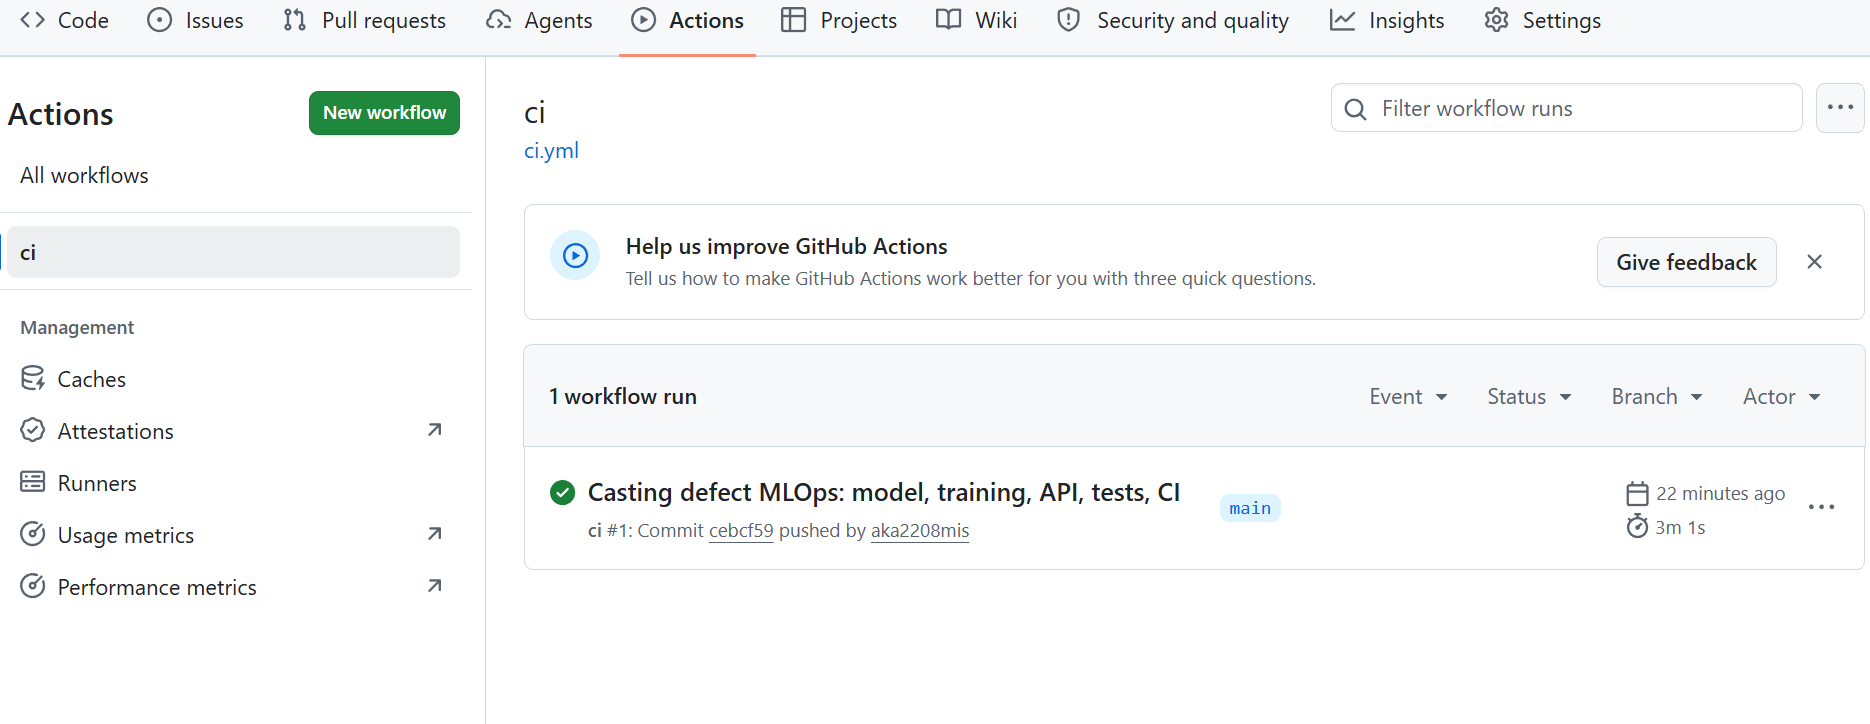

Successful Docker build: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/submission/evidence/docker_build.png


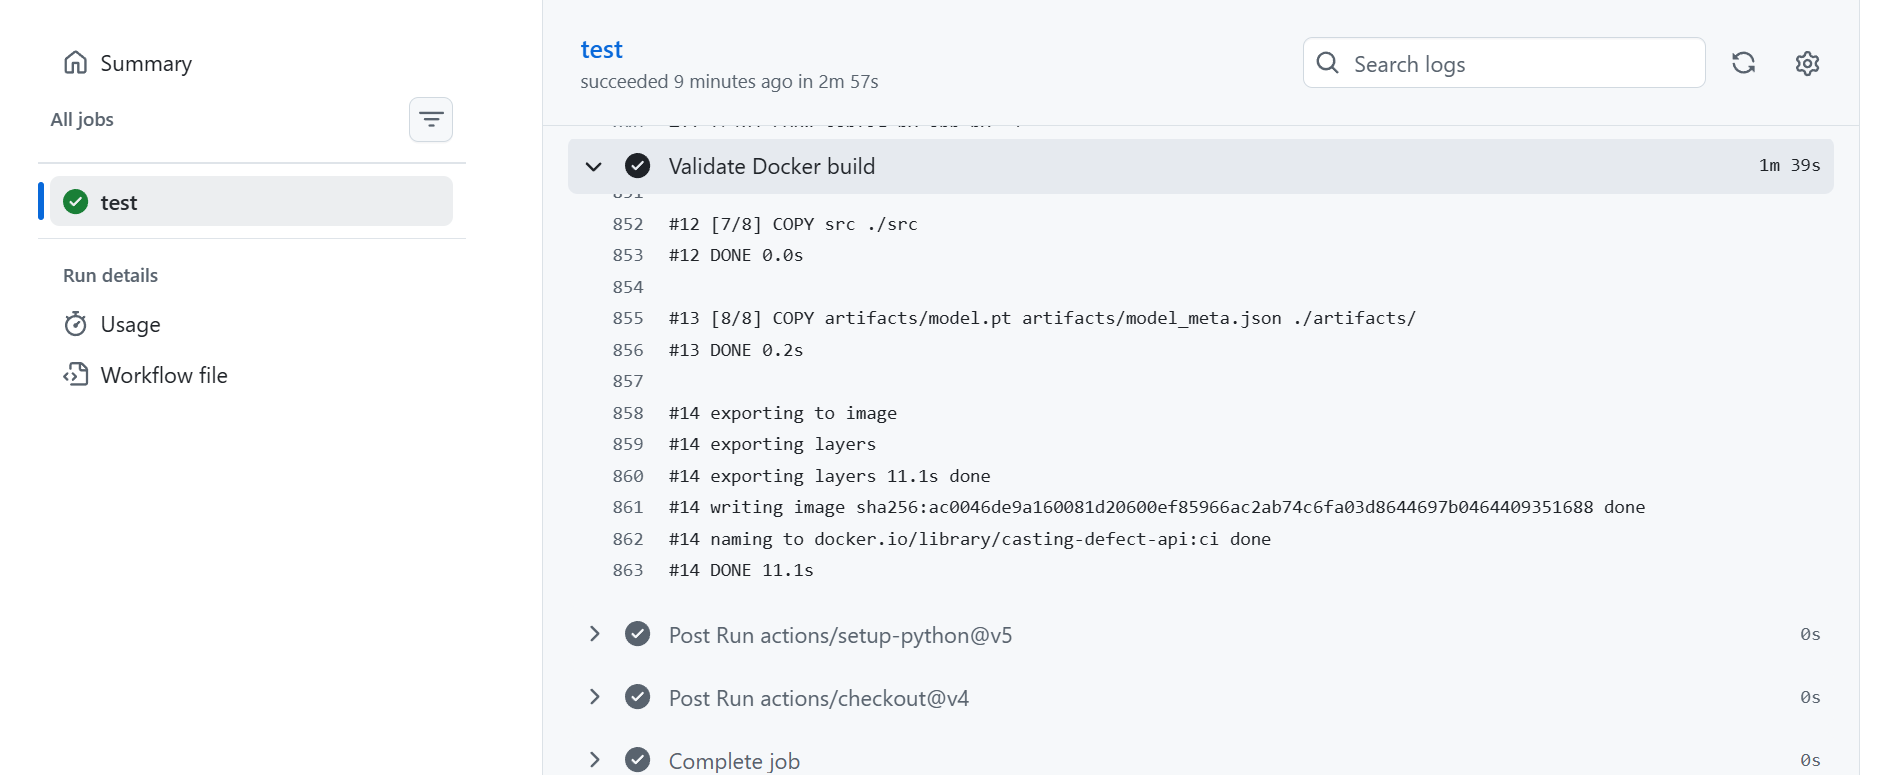


Evidence summary saved to: /content/drive/MyDrive/Casting_Defect_MLOps_Capstone/submission/evidence/stage_3_4_summary.txt


**Stage 3.4 results:** pytest **passed**. Docker build: not run here (no Docker in Colab); see the CI screenshot. CI screenshot included; Docker screenshot included.

In [23]:
# TODO 3.4.1-3.4.2: print Dockerfile + ci.yml; run pytest; embed your CI/Docker screenshots
DOCKERFILE_PATH = PROJECT_DIR / "Dockerfile"
CI_PATH = PROJECT_DIR / ".github" / "workflows" / "ci.yml"

for title, path in (("Dockerfile", DOCKERFILE_PATH), ("GitHub Actions CI", CI_PATH)):
    print(f"\n--- {title}: {path.relative_to(PROJECT_DIR)} ---")
    print(path.read_text(encoding="utf-8") if path.is_file() else "FILE NOT FOUND")

# 3.4.2: run the test suite against the current src/ and app.py.
pytest_exit_code = run_and_stream(
    [sys.executable, "-m", "pytest", "-q"], "pytest", check=False
)
pytest_passed = pytest_exit_code == 0
print("pytest result:", "PASS" if pytest_passed else f"FAIL (exit code {pytest_exit_code})")

# Colab has no Docker daemon; the build is verified by CI (screenshot below).
docker_executable = shutil.which("docker")
if docker_executable is None:
    docker_status = "not run here (no Docker in Colab); see the CI screenshot"
    print("\nDocker build:", docker_status)
else:
    docker_exit = run_and_stream(
        [docker_executable, "build", "-t", "casting-defect-api:stage-3-4", "."],
        "Docker build", check=False,
    )
    docker_status = "PASS" if docker_exit == 0 else f"FAIL (exit code {docker_exit})"

print()
ci_shot = show_evidence("github_actions_ci.png", "GitHub Actions green run")
docker_shot = show_evidence("docker_build.png", "Successful Docker build")

summary_path = EVIDENCE_DIR / "stage_3_4_summary.txt"
summary_path.write_text(
    f"pytest: {'PASS' if pytest_passed else 'FAIL'} (exit code {pytest_exit_code})\n"
    f"Docker build: {docker_status}\n"
    f"GitHub Actions screenshot present: {ci_shot}\n"
    f"Docker build screenshot present: {docker_shot}\n",
    encoding="utf-8",
)
print("\nEvidence summary saved to:", summary_path)

display(Markdown(
    f"**Stage 3.4 results:** pytest **{'passed' if pytest_passed else 'FAILED'}**. "
    f"Docker build: {docker_status}. CI screenshot "
    f"{'included' if ci_shot else 'missing'}; Docker screenshot "
    f"{'included' if docker_shot else 'missing'}."
))

### 3.4 Containerisation and CI — review

**3.4.1 Dockerfile**

- It starts from `python:3.11-slim` and installs the **CPU-only** torch/torchvision wheels, which keeps the image far smaller than CUDA builds, followed by pinned versions of the other dependencies.
- It copies only what serving needs: `config.py`, `app.py`, `src/`, `artifacts/model.pt` and `model_meta.json`.
- It exposes port 8000 and starts `uvicorn app:app`.

Review notes, worth mentioning in the report:

- **`metrics.json` is not copied into the image.** If `/health` reports test metrics, as it does in the demo above, the container's `/health` will not show them. Adding `artifacts/metrics.json` to the `COPY` line fixes this.
- **Versions are pinned twice.** `requirements.txt` is copied, but the versions are repeated inline in the Dockerfile and again in `ci.yml`. If any of the three is edited, they can silently drift apart. Installing from one file would avoid that.
- **The container runs as root and has no `HEALTHCHECK`.** A non-root `USER` and `HEALTHCHECK CMD` hitting `/health` are the usual production hardening steps.

**3.4.2 GitHub Actions CI** (`.github/workflows/ci.yml`)

- On every push to `main` and on every pull request, it sets up Python 3.11 and installs the CPU dependencies.
- It runs **`pytest -q`**, then **builds the Docker image**. A broken test or a broken image therefore fails the pipeline before anything is deployed.
- The Docker build needs `artifacts/model.pt` to be **committed**: a fully trained checkpoint is about 45 MB, which is under GitHub's 100 MB file limit. If `artifacts/` is git-ignored, the CI build step fails.

**Evidence:** the pytest output above, plus screenshots of the green GitHub Actions run and the successful Docker build. Colab has no Docker daemon, so the build is evidenced by CI.